In [2]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

In [3]:
def f_rec(n):
    """
    Returns the recycling fraction f_rec(n) for a given Lyman series level n.
    Values based on Pritchard & Furlanetto (2006) / Hirata (2006).
    
    Args:
        n (int): Principal quantum number (n >= 2).
        
    Returns:
        float: The recycling fraction f_rec.
    """
    # Array indices 0 to 30
    # Values mapped to index n
    f_rec_values = np.array([
        0.0,      # n=0 (Invalid)
        0.0,      # n=1 (Ground state, Invalid)
        1.0000,   # n=2 (Ly-alpha)
        0.0000,   # n=3 (Ly-beta)
        0.2609,   # n=4
        0.3078,   # n=5
        0.3259,   # n=6
        0.3353,   # n=7
        0.3410,   # n=8
        0.3448,   # n=9
        0.3476,   # n=10
        0.3496,   # n=11
        0.3512,   # n=12
        0.3524,   # n=13
        0.3535,   # n=14
        0.3543,   # n=15
        0.3550,   # n=16
        0.3556,   # n=17
        0.3561,   # n=18
        0.3565,   # n=19
        0.3569,   # n=20
        0.3572,   # n=21
        0.3575,   # n=22
        0.3578,   # n=23
        0.3580,   # n=24
        0.3582,   # n=25
        0.3584,   # n=26
        0.3586,   # n=27
        0.3587,   # n=28
        0.3589,   # n=29
        0.3590    # n=30
    ])
    
    # Return value based on n
    if n < len(f_rec_values):
        return f_rec_values[n]
    else:
        # For n > 30, the value approaches 0.359 asymptotically
        return 0.359

#for i in range(0, 31):
#    print(i, f_rec(i))

In [4]:
NU_LYMAN_ALPHA = 2.466e15 # n=2 (Ly_alpha)
NU_LYMAN_BETA  = 2.925e15 # n=3 (Ly_beta)
NU_LYMAN_GAMMA = 3.083e15 # n=4 (Ly_gamma)
NU_LYMAN_DELTA = 3.158e15 # n=5 (Ly_delta)
NU_LYMAN_LIMIT = 3.289e15 # Hz (n=infinity, ionization potential)

# Planck's constant (erg s)
PLANCK = 6.62607015e-27
# Wavelength of 21 cm
LAMBDA_21cm = 21.106 
# Wavelength of Lyman-alpha (1215.67 Angstroms, converted to cm)
LAMBDA_1216 = 1215.67e-8

# Boltzmann constant (ergs per kelvin)
k_B = 1.381e-16 
# Hubble constant (Little h)
h = 0.6774
# Hubble constant at the present day
H_0 = 100 * h
H_0_cgs = 100.0 * h * 3.241e-20 # convert from km/s/Mpc to cm^{-1}
# Spontaneous decay rate of the spin-flip transition A_10 (per s)
# Spontaneous emission coeﬃcient of the 21 cm transition
A_10 = 2.85e-15 

M_SOL = 1.988e33 # 1 Solar mass in grams
YR = 31556736
G_cgs = 6.6743015e-8 # Gravitational Constant #dyn cm^2 g^{−2}
m_p = 1.6738e-24 # Neutral hydrogen mass
e_cgs = 4.803204712570263e-10   # statC (esu)
me_cgs = const.m_e.cgs.value    # g
C_LIGHT  = const.c.cgs.value      # cm / s
X_H = 0.76 # hydrogen fraction
msol_cgs = 1.98847e33
yr_sec = 3.15576e7 

OMEGA_b = 0.0486 # THESAN (Kannan et al. 2022) / 0.044 (Furlanetto et al. 2006)
OMEGA_m = 0.3089 # THESAN (Kannan et al. 2022)  / 0.26 (Furlanetto et al. 2006)
OMEGA_Lambda = 0.6911 #THESAN (Kannan et al. 2022) / 0.74 (Furlanetto et al. 2006)
HYDROGEN_MASSFRAC = 0.76 # global hydrogen mass fraction
y_frac = (1.0 - HYDROGEN_MASSFRAC) / (4.0 * HYDROGEN_MASSFRAC)

# T_star (kelvin)
T_star = PLANCK * C_LIGHT / (k_B * LAMBDA_21cm)

In [5]:
# -------------------------------------------------------------
# 1. Load the spectrum table (equivalent to mrt_load_spectrum_table())
# -------------------------------------------------------------
class SpectrumTable:
    def __init__(self, filename):
        self.filename = filename
        self._load()

    def _load(self):
        with h5py.File(self.filename, "r") as f:

            # Dimensions (AREPO: Number_of_freq, N_age, N_metallicity)
            self.Nfreq = int(f["Number_of_freq"][()])
            self.N_age = int(f["N_age"][()]) if "N_age" in f else 1
            self.N_metallicity = int(f["N_metallicity"][()]) if "N_metallicity" in f else 1

            # Energy array
            self.PhotEnergy = f["Energy"][()]  # eV, length Nfreq
            self.freq = f["freq"][()]  # Hz, length Nfreq
            freq = self.freq.reshape(1, 1, self.Nfreq)

            # Luminosity array (erg/s/Hz/Msol)
            Lnu = f["Lnu"][()]  # length Nfreq * N_age * N_metallicity
            Lnu = Lnu.reshape(self.N_metallicity, self.N_age, self.Nfreq)

            # Convert erg/s/Hz/Msol → photons/s/Hz/baryon (same as AREPO: divide by PLANCK)
            # compute epsilon_b
            self.LumPhotons = (Lnu / (PLANCK * freq)) * (m_p / M_SOL)

            # flatten back to original AREPO-style layout
            self.LumPhotons = self.LumPhotons.reshape(-1)

            # Age array (Gyr)
            if self.N_age > 1:
                age_arr = f["age"][()]
                age_arr[age_arr < 1e-6] = 1e-6
                self.AgeGyr = age_arr
                self.LogAge = np.log10(age_arr)
            else:
                self.LogAge = np.array([0.0])
                self.AgeGyr = np.array([0.0])

            # Metallicity array (Z)
            if self.N_metallicity > 1:
                self.Metallicity = f["metallicity"][()]
                self.LogMetallicity = np.log10(self.Metallicity)
            else:
                self.LogMetallicity = np.array([0.0])
                self.Metallicity = np.array([0.0])


        print("Loaded spectrum table:")
        print(f"  Nfreq = {self.Nfreq}")
        print(f"  N_age = {self.N_age}")
        print(f"  N_metallicity = {self.N_metallicity}")

    # -------------------------------------------------------------
    # 2. Return *full spectrum* for given age & metallicity
    # -------------------------------------------------------------
    def full_spectrum(self, i_age, i_metallicity):
        """Returns (Frequency array, LumPhotons array) for specific Z and age indices."""
        # Indexing: Z (outer) -> Age (middle) -> Freq (inner)
        offset = i_metallicity * self.N_age * self.Nfreq + i_age * self.Nfreq
        return self.freq, self.LumPhotons[offset:offset + self.Nfreq]

In [6]:
# -------------------------------------------------------------
# 3. Main Execution and Plotting Loop
# -------------------------------------------------------------

# Load the table (Update this path if necessary, but it looks correct)
HDF5_FILEPATH = "/orcd/data/mvogelsb/004/ozier/ZOOM_XL/sharedData/bpass_spectra_bin_chab100_v2.2.1.hdf5"
try:
    spec = SpectrumTable(HDF5_FILEPATH)
except FileNotFoundError:
    print(f"ERROR: Could not find the file at {HDF5_FILEPATH}. Please ensure the path is correct.")
    exit()
except Exception as e:
    print(f"ERROR: Failed to load HDF5 data: {e}")
    exit()


# 1. Does the frequency axis agree with the (unused) energy axis?
#EV = 1.602176634e-12
#print(np.allclose(spec.PhotEnergy*EV/6.62607015e-27, spec.freq, rtol=1e-6))

# 2. Layout sanity: L at 1216 A vs age, one curve per metallicity
#i = np.argmin(np.abs(spec.freq - 2.466e15))
#L = spec.LumPhotons.reshape(spec.N_metallicity, spec.N_age, spec.Nfreq)[:, :, i]
#for k in range(spec.N_metallicity):
#    plt.loglog(spec.AgeGyr, L[k], label=f"Z={spec.Metallicity[k]:.0e}")
#plt.legend(fontsize=6)


Loaded spectrum table:
  Nfreq = 100000
  N_age = 34
  N_metallicity = 13


In [7]:
def get_spec(Z_target):
    # find index
    iZ = np.where(spec.Metallicity == Z_target)[0][0]
    print("Metallicity index:", iZ)
    all_spectra = []
    all_ages = spec.AgeGyr.copy()
    for i_age in range(spec.N_age):
        freq, lum = spec.full_spectrum(i_age, iZ)
        all_spectra.append(lum)
    all_spectra = np.array(all_spectra)
    # shape = (N_age, Nfreq)

    # log-spaced bin edges (BPASS grid: 0.1 dex in log age)
    log_age_yr = np.log10(all_ages * 1.0e9)      # AgeGyr -> log10(age / yr)
    dlog = np.median(np.diff(log_age_yr))        # 0.1
    edge_hi = 10**(log_age_yr + dlog/2)
    edge_lo = 10**(log_age_yr - dlog/2)
    edge_lo[0] = 0.0                             # first bin runs from t = 0

    # conversion factor
    yr_to_sec = 3.15576e7                        # seconds in 1 yr
    dt_sec = (edge_hi - edge_lo) * yr_to_sec

    # reshape dt so it broadcasts along frequency axis
    dt_sec_2d = dt_sec[:, None]   # shape (N_age, 1)
    # time integration
    N_nu = np.sum(all_spectra * dt_sec_2d, axis=0)

    #testing
    i = np.argmin(np.abs(freq - NU_LYMAN_ALPHA))
    c = np.cumsum(all_spectra[:, i] * dt_sec); c /= c[-1]
    for f in (0.5, 0.9, 0.99):
        print(f, np.interp(f, c, all_ages)*1e3, "Myr")
    return freq, N_nu



freq, N_nu_5 = get_spec(1.0e-5)
freq, N_nu_4 = get_spec(1.0e-4)
freq, N_nu_3 = get_spec(1.0e-3)
freq, N_nu_2 = get_spec(1.0e-2)


band = (freq >= NU_LYMAN_ALPHA) & (freq <= NU_LYMAN_LIMIT)
for lab, N in [("1e-5",N_nu_5),("1e-4",N_nu_4),("1e-3",N_nu_3),("1e-2",N_nu_2)]:
    print(lab, np.trapezoid(N[band], freq[band]))

Metallicity index: 0
0.5 5.5352703459888755 Myr
0.9 31.153521709272596 Myr
0.99 132.9684760980478 Myr
Metallicity index: 1
0.5 4.368563247896205 Myr
0.9 15.66627954424745 Myr
0.99 78.57402523878571 Myr
Metallicity index: 2
0.5 3.9058768688663728 Myr
0.9 13.258537797753178 Myr
0.99 82.69337757778406 Myr
Metallicity index: 8
0.5 3.323884605512593 Myr
0.9 9.308117639046568 Myr
0.99 43.250059332194354 Myr
1e-5 22003.362460227116
1e-4 20583.6540539257
1e-3 17618.240734662646
1e-2 14069.241743739909


In [8]:
# time-integrate once per tabulated metallicity -> shape (N_Z, Nfreq)
N_all     = np.array([get_spec(Z)[1] for Z in spec.Metallicity])
logZ_grid = np.log10(spec.Metallicity)

def N_nu_at(Z):
    """Time-integrated photons/Hz/baryon at arbitrary Z, linear in log Z; clamped to the grid."""
    lz = np.log10(max(Z, spec.Metallicity[0]))           # Z <= 0 or below grid -> lowest grid point
    lz = np.clip(lz, logZ_grid[0], logZ_grid[-1])
    j  = np.clip(np.searchsorted(logZ_grid, lz) - 1, 0, len(logZ_grid) - 2)
    w  = (lz - logZ_grid[j]) / (logZ_grid[j+1] - logZ_grid[j])
    return (1 - w) * N_all[j] + w * N_all[j+1]

band = (freq >= NU_LYMAN_ALPHA) & (freq <= NU_LYMAN_LIMIT)
df["N_Lyband"] = [np.trapezoid(N_nu_at(Z)[band], freq[band]) for Z in df["Z_mean_mw"]]
#df[["redshift", "Z_mean_mw", "N_Lyband"]]

Metallicity index: 0
0.5 5.5352703459888755 Myr
0.9 31.153521709272596 Myr
0.99 132.9684760980478 Myr
Metallicity index: 1
0.5 4.368563247896205 Myr
0.9 15.66627954424745 Myr
0.99 78.57402523878571 Myr
Metallicity index: 2
0.5 3.9058768688663728 Myr
0.9 13.258537797753178 Myr
0.99 82.69337757778406 Myr
Metallicity index: 3
0.5 3.778367672222674 Myr
0.9 12.262154901242162 Myr
0.99 77.459241718882 Myr
Metallicity index: 4
0.5 3.7491409843804284 Myr
0.9 11.842898233177719 Myr
0.99 79.8149032380173 Myr
Metallicity index: 5
0.5 3.8883709839627048 Myr
0.9 11.248080779021729 Myr
0.99 59.12187149760692 Myr
Metallicity index: 6
0.5 3.753216800590371 Myr
0.9 10.637825862817149 Myr
0.99 53.25020068841957 Myr
Metallicity index: 7
0.5 3.6431432011577467 Myr
0.9 10.012562259795416 Myr
0.99 54.57774597403029 Myr
Metallicity index: 8
0.5 3.323884605512593 Myr
0.9 9.308117639046568 Myr
0.99 43.250059332194354 Myr
Metallicity index: 9
0.5 3.107554637907103 Myr
0.9 8.811520850490208 Myr
0.99 41.771148040

NameError: name 'df' is not defined

In [9]:
# ============================================================
# Collisional de-excitation rate tables (precomputed once)
# ============================================================

# --- H–H collisions ---
_T_HH = np.log10([
    1, 2, 4, 6, 8, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 500, 700, 1000, 2000, 3000, 5000, 7000, 10000
])

_k_HH = np.log10([
    1.38e-13, 1.43e-13, 2.71e-13, 6.60e-13, 1.47e-12, 2.88e-12,
    9.10e-12, 1.78e-11, 2.73e-11, 3.67e-11, 5.38e-11, 6.86e-11,
    8.14e-11, 9.25e-11, 1.02e-10, 1.11e-10, 1.19e-10, 1.75e-10,
    2.09e-10, 2.56e-10, 2.91e-10, 3.31e-10, 4.27e-10, 4.97e-10,
    6.03e-10, 6.87e-10, 7.87e-10
])


# --- e–H collisions ---
_T_eH = np.log10([
    1, 2, 5, 10, 20, 50, 100, 200, 500, 1000,
    2000, 3000, 5000, 7000, 10000, 15000, 20000
])

_k_eH = np.log10([
    2.39e-10, 3.37e-10, 5.30e-10, 7.46e-10, 1.05e-9, 1.63e-9,
    2.26e-9, 3.11e-9, 4.59e-9, 5.92e-9, 7.15e-9, 7.71e-9,
    8.17e-9, 8.32e-9, 8.37e-9, 8.29e-9, 8.11e-9
])


# --- p–H collisions ---
_T_pH = _T_eH.copy()

_k_pH = np.log10([
    0.40e-9, 0.45e-9, 0.430e-9, 0.369e-9, 0.317e-9, 0.3047e-9,
    0.3379e-9, 0.4043e-9, 0.5471e-9, 0.7051e-9, 0.9167e-9,
    1.070e-9, 1.301e-9, 1.480e-9, 1.695e-9, 1.975e-9, 2.201e-9
])

def kappa_HH(T_K):
    """
    H–H collisional de-excitation rate coefficient (cm^3 s^-1).
    """
    # Build interpolator once
    interp_func = CubicSpline(_T_HH, _k_HH)

    # Evaluate
    k_interp = interp_func(np.log10(T_K))
    return 10.0 ** k_interp #np.interp(np.log10(T_K), _T_HH, _k_HH)


def kappa_eH(T_K):
    """
    e–H collisional de-excitation rate coefficient (cm^3 s^-1).
    """
    # Build interpolator once
    interp_func = CubicSpline(_T_eH, _k_eH)

    # Evaluate
    k_interp = interp_func(np.log10(T_K))
    return 10.0 ** k_interp #np.interp(np.log10(T_K), _T_eH, _k_eH)


def kappa_pH(T_K):
    """
    p–H collisional de-excitation rate coefficient (cm^3 s^-1).
    """

    # Build interpolator once
    interp_func = CubicSpline(_T_pH, _k_pH)

    # Evaluate
    k_interp = interp_func(np.log10(T_K))
    return 10.0 ** k_interp


# --- Data Generation ---
# Create an array of T_K values from 1 (10^0) to 10000 (10^4)
# We use np.logspace to get points evenly spaced in log scale
T_K_plot = np.logspace(0, 5, 400)  # 400 points from 1 to 10000

# Calculate the corresponding interpolated kappa values
kappa_plot = kappa_HH(T_K_plot)
kappa_plot_eH = kappa_eH(T_K_plot)
kappa_plot_pH = kappa_pH(T_K_plot)


# --- Plotting ---
#print("Generating plot...")

# Set up the plot
#plt.figure(figsize=(9, 8))

# Plot the interpolated line
#plt.loglog(T_K_plot, kappa_plot, '--', color='#fe218b', label=r'$\kappa^{HH}_{10}$')
#plt.loglog(T_K_plot, kappa_plot_eH, ':', color='#06d6a0', label=r'$\kappa^{eH}_{10}$')
#plt.loglog(T_K_plot, kappa_plot_pH,  color='#21b0fe', label=r'$\kappa^{pH}_{10}$')


# Plot the original data points to verify the fit
#plt.loglog(T_K_values_HH, kappa_values_HH, 'o', color='#fe218b')
#plt.loglog(T_K_values_eH, kappa_values_eH, 'o', color='#06d6a0')
#plt.loglog(T_K_values_pH, kappa_values_pH, 'o', color='#21b0fe')


# --- Customize the Plot ---
# Set axis scales (already loglog, but good to be explicit)
#plt.xscale('log')
#plt.yscale('log')

# Set axis limits
#plt.xlim(1, 10000)
#plt.ylim(8.0e-14, 1.0e-7)

# Add title and labels (using LaTeX for nice formatting)
#plt.xlabel(r'$T_K$ (K)', fontsize=15)
#plt.ylabel(r'$\kappa$ (cm$^3$ s$^{-1}$)', fontsize=15)

# Add a legend
#plt.legend(loc="lower right", fontsize=15)

# Add grid lines for better readability
#plt.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Save the plot to a file
#plt.savefig('collisional_rate_vs_temp.png', dpi=300)

# Display the plot
#print("Plot saved as 'collisional_rate_vs_temp.png'")
#plt.show()

In [10]:
#def num_den_b(z):
#    rho_crit = (3.0 * H_0_cgs * H_0_cgs) / (8.0 * np.pi * G_cgs)
#    return OMEGA_b * rho_crit * (1.0 + z)**(3.0) / m_p
    
# Hubble parameter at z: H(z)
def H_cgm(z):
    """
    Calculates the Hubble parameter H(z) at a given redshift z.
    Assumes a flat Lambda-CDM cosmology.
    """
    return H_0_cgs * (OMEGA_m * (1.0 + z)**3.0 + OMEGA_Lambda)**0.5

# Hubble parameter at z: H(z)
def H(z):
    return H_0 * (OMEGA_m * (1.0 + z)**3.0 + OMEGA_Lambda)**0.5

# CMB brightness temperature at z: T_CMB(z)
def T_CMB(z):
    T_CMB_0 = 2.7255 # Kelvin
    return T_CMB_0 * (1.0 + z)

def x_c(z):
    #print(T_K(z), kappa_HH(T_K(z)), kappa_eH(T_K(z)), kappa_pH(T_K(z)), n_H(z), n_e(z), n_p(z), T_gamma(z))
    return T_star * (kappa_HH(T_K(z)) * n_H(z) + kappa_eH(T_K(z)) * n_e(z) + kappa_pH(T_K(z)) * n_p(z)) / (A_10 * T_gamma(z))

def tau_GP(z):
#Gunn-Peterson optical depth (dimensionless) for hydrogen
    return 3.0e5 * HI_frac(z) * ((1.0+z)/7.0)**1.5

def S_alpha(z):
# Suppression factor for hydrogen
    return np.exp(-0.803*(T_K(z)**(-2.0/3.0)) * (1.0e-6*tau_GP(z))**(1.0/3.0))
    
def tau_GP_He(z):
#Gunn-Peterson optical depth (dimensionless) for helium
    return 6.0e3 * HeII_frac(z) * ((1.0+z)/7.0)**1.5

def S_alpha_He(z):
# Suppression factor for helium (this is same as the hydrogen)
    return np.exp(-0.803*(T_K_He(z)**(-2.0/3.0)) * (1.0e-6*tau_GP_He(z))**(1.0/3.0))


def cosmic_time(z):
    """
    Cosmic time at redshift z (seconds).
    Uses your H_cgm(z).
    """
    integrand = lambda zp: 1.0 / ((1.0 + zp) * H_cgm(zp))
    
    # First compute age of universe today
    t0, _ = quad(integrand, 0.0, 1e4)   # 1e4 is effectively infinity
    
    # Then subtract integral from 0 to z
    tz_part, _ = quad(integrand, 0.0, z)
    
    return t0 - tz_part

In [14]:
# 1. Define paths
path_dir = (
    "/orcd/data/mvogelsb/004/chcho/global/"
)
#"/orcd/data/mvogelsb/004/chcho/PS_21cm/new_parallel_PS21cm/global/"
redshift_file = path_dir + "redshift.txt"

hii_file = path_dir + "means_HII.txt"
heii_file = path_dir + "means_HeII.txt"
heiii_file = path_dir + "means_HeIII.txt"

temp_file = path_dir + "means_T.txt"
neutral_temp_file = path_dir + "neutral_temp_means.txt"
neutral_temp_ad_file = path_dir + "neutral_temp_noxray.txt" #"neutral_temp_noxray_1e-4.txt" #"neutral_temp_noxray.txt"

neutral_temp_med_file = path_dir + "neutral_temp_median.txt"
neutral_temp_1e3_file = path_dir + "neutral_temp_means_0.001.txt"
neutral_temp_med_1e3_file = path_dir + "neutral_temp_median_0.001.txt"


sfr_file = path_dir + "means_SFR.txt"
rho_file = path_dir + "means_Density.txt"
agn_file = path_dir + "means_LuminosityAGN.txt"


# 2. Read the files
df_z = pd.read_csv(redshift_file, names=["redshift"])

# FIX: Swapped out 'delim_whitespace=True' for 'sep=r"\s+"'
df_hii = pd.read_csv(hii_file, sep=r"\s+", names=["snapshot", "f_HII"])
df_heii = pd.read_csv(heii_file, sep=r"\s+", names=["snapshot", "f_HeII"])
df_heiii = pd.read_csv(heiii_file, sep=r"\s+", names=["snapshot", "f_HeIII"])
df_temp = pd.read_csv(temp_file, sep=r"\s+", names=["snapshot", "T_vol"])
df_temp_neutral = pd.read_csv(neutral_temp_file, sep=r"\s+", names=["snapshot", "T_vol"])
df_temp_neutral_ad = pd.read_csv(neutral_temp_ad_file, sep=r"\s+", names=["snapshot", "T_vol"])
df_sfr = pd.read_csv(sfr_file, sep=r"\s+", names=["snapshot", "SFR"])
df_rho = pd.read_csv(rho_file, sep=r"\s+", names=["snapshot", "Density"])
df_agn = pd.read_csv(agn_file, sep=r"\s+", names=["snapshot", "LuminosityAGN"])
df_temp_neutral_1e3 = pd.read_csv(neutral_temp_1e3_file, sep=r"\s+", names=["snapshot", "T_vol"])
df_temp_neutral_med = pd.read_csv(neutral_temp_med_file, sep=r"\s+", names=["snapshot", "T_vol_med"])
df_temp_neutral_med_1e3 = pd.read_csv(neutral_temp_med_1e3_file, sep=r"\s+", names=["snapshot", "T_vol_med"])

# 3. Combine them side-by-side
df = df_hii.copy()  # Starts with columns: snapshot, f_HII
df["redshift"] = df_z["redshift"]
df["f_HeII"] = df_heii["f_HeII"]  # <-- Added Helium II fraction column
df["f_HeIII"] = df_heiii["f_HeIII"]  # <-- Added Helium II fraction column
df["T_vol"] = df_temp["T_vol"]  # <-- Added Temperature column
df["T_neutral"] = df_temp_neutral["T_vol"]  # <-- Added Temperature column
df["T_neutral_ad"] = df_temp_neutral_ad["T_vol"]  # <-- Added Temperature column
df["SFRD"] = df_sfr["SFR"] *6.301081197556214e+25/1.4009476382893126e+73 # <-- unit conversion
df["Density"] = df_rho["Density"]  # <-- Added Temperature column
df["LuminosityAGN"] = df_agn["LuminosityAGN"] * 6.45e36

df["T_neutral_1e-3"] = df_temp_neutral_1e3["T_vol"]  # <-- Added Temperature column
df["T_neutral_med"] = df_temp_neutral_med["T_vol_med"]  # <-- Added Temperature column
df["T_neutral_med_1e-3"] = df_temp_neutral_med_1e3["T_vol_med"]  # <-- Added Temperature column

# 4. Enforce clean data types
df["snapshot"] = df["snapshot"].astype(int)

# 5. Reorder columns logically (Snapshot -> Redshift -> Fractions -> Temperature)
df = df[["snapshot", "redshift", "f_HII", "f_HeII", "f_HeIII", "T_vol", "T_neutral", "SFRD", "Density", "LuminosityAGN", "T_neutral_ad", "T_neutral_med", "T_neutral_1e-3", "T_neutral_med_1e-3"]]


print("Total rows combined:", len(df))
#df

Total rows combined: 709


Text(0, 0.5, 'Temperature [K]')

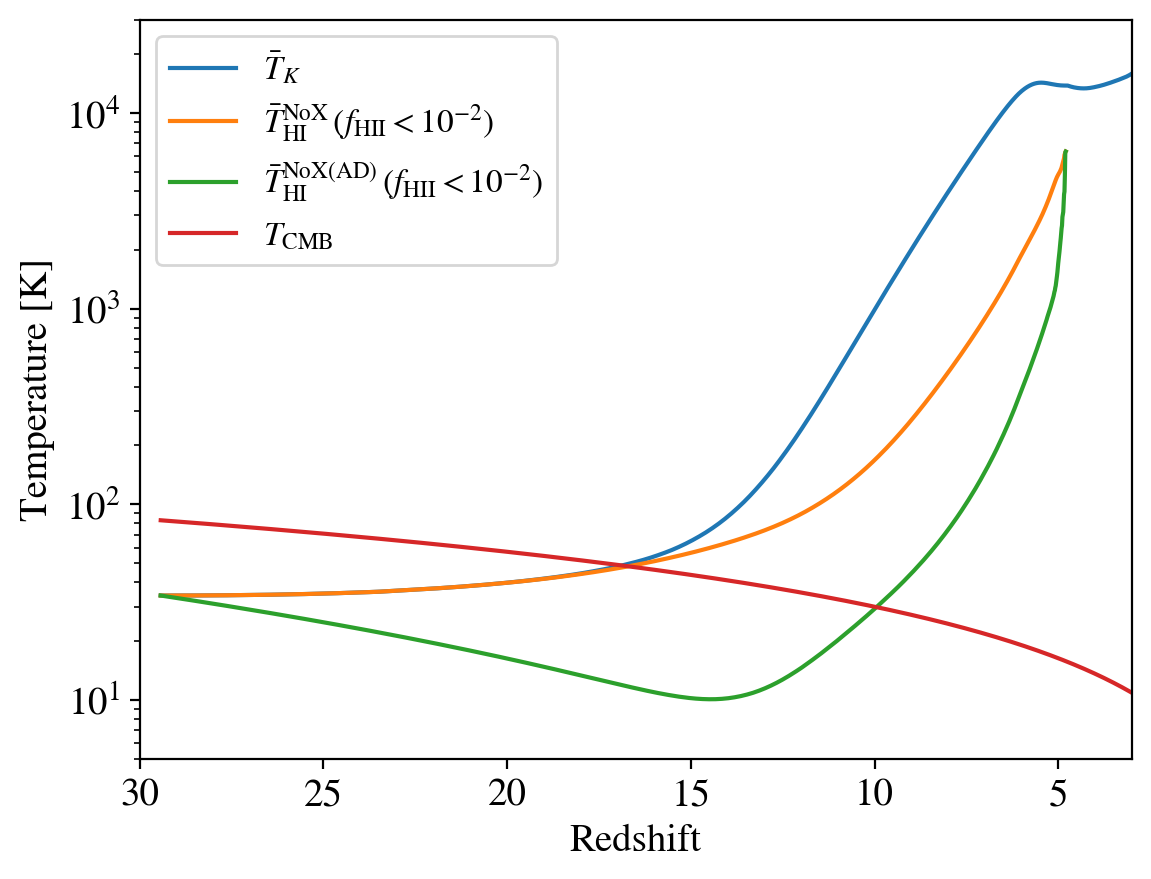

In [15]:
plt.plot(df["redshift"], df["T_vol"], label=r"$\bar{T}_K$")

plt.plot(df["redshift"], df["T_neutral"], label=r"$\bar{T}^\mathrm{No X}_\mathrm{H I} \, (f_\mathrm{HII} < 10^{-2}$)" )
#plt.plot(df["redshift"], df["T_neutral_1e-3"], label=r"$\bar{T}^\mathrm{No X}_\mathrm{H I} \, (f_\mathrm{HII} < 10^{-3}$)" )
plt.plot(df["redshift"], df["T_neutral_ad"], label=r"$\bar{T}^\mathrm{No X (AD)}_\mathrm{H I} \, (f_\mathrm{HII} < 10^{-2}$)" )


#plt.plot(df["redshift"], df["T_neutral_med"], label=r"median $T^\mathrm{No X}_\mathrm{H I} \, (f_\mathrm{HII} < 10^{-2}$)" )
#mask = df["T_neutral_med_1e-3"] >= 1

#plt.plot(
#    df["redshift"][mask], 
#    df["T_neutral_med_1e-3"][mask], 
#    label=r"median $T^\mathrm{No X}_\mathrm{H I} \, (f_\mathrm{HII} < 10^{-3}$)"
#)
plt.plot(df["redshift"], 2.7255 * (1.0 + df["redshift"]), label=r"$T_\mathrm{CMB}$")
plt.legend(fontsize=12)
plt.yscale("log")
plt.xlim(30,3)
plt.ylim(5,3e4)


plt.xlabel("Redshift")
plt.ylabel("Temperature [K]")

In [11]:
df["H_cgm"] = H_cgm(df["redshift"])
df["H(z)"] = H(df["redshift"])
df["T_CMB"] = T_CMB(df["redshift"])

df["rho_H"] = HYDROGEN_MASSFRAC * df["Density"] * 3.0991811197281837e-22*(1+df["redshift"])**3.0 # total hydrogen mass density
df["num_H"] = df["rho_H"] / m_p # total hydrogen number density

df["frac_HI"] = (1.0 - df["f_HII"]) # neutral hydrogen fraction (mass-weighted)
df["num_HI"] = df["frac_HI"] * df["num_H"]   # neutral hydrogen number density
df["num_HII"] = df["f_HII"] * df["num_H"]    # ionized hydrogen number density


df["num_He"] = y_frac * df["num_H"]           # total helium number density
df["num_HeII"] = df["f_HeII"] * df["num_H"] # single ionized helium number density
df["num_HeIII"] = df["f_HeIII"] * df["num_H"]   # fully-ionized helium number density
df["num_HeI"] = (y_frac - df["f_HeIII"] - df["f_HeII"]) * df["num_H"] # neutral helium number density

df["f_HeII"] = df["num_HeII"] / (df["num_HeI"] + df["num_HeII"] + df["num_HeIII"]) # ionized Helium fraction
    
df["num_p"] = df["num_HII"]
df["num_e"] = df["num_HII"] + df["num_HeII"] + 2.0 * df["num_HeIII"] # electron number density 

In [12]:
HYDROGEN_MASSFRAC, y_frac

(0.76, 0.07894736842105263)

In [13]:
df_global = pd.read_csv("/orcd/data/mvogelsb/004/chcho/LUMINA_ALL_Z_1.0e-2.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/orcd/data/mvogelsb/004/chcho/LUMINA_ALL_Z_1.0e-2.csv'

In [ ]:
df_global["J_alpha"]

In [ ]:
def den_b(z):
    rho_crit_0 = (3.0 * H_0_cgs * H_0_cgs) / (8.0 * np.pi * G_cgs)
    return OMEGA_b * rho_crit_0 * (1.0 + z)**(3.0)

def num_b(z):
    rho_crit_0 = (3.0 * H_0_cgs * H_0_cgs) / (8.0 * np.pi * G_cgs)
    return OMEGA_b * rho_crit_0 * (1.0 + z)**(3.0) / m_p


In [ ]:
plt.plot(df_global["redshift"], den_b(df_global["redshift"])) #df_global["density"])
plt.plot(df["redshift"], df["Density"]* 3.0991811197281837e-22*(1+df["redshift"])**3.0)
#plt.plot(df["redshift"], den_b()
plt.xlim(30,3)

In [ ]:
plt.plot(df_global["redshift"], den_b(df_global["redshift"])) #df_global["density"])
plt.plot(df["redshift"], df["Density"]* 3.0991811197281837e-22*(1+df["redshift"])**3.0)
#plt.plot(df["redshift"], den_b()
plt.xlim(30,3)

In [ ]:
plt.plot(df_global["redshift"], df_global["num_HeIII"])
plt.plot(df["redshift"], df["num_HeIII"])
plt.xlim(30,3)

In [ ]:
plt.plot(df_global["redshift"], df_global["f_HII"])
plt.plot(df["redshift"], df["f_HII"])
plt.xlim(30,3)

In [ ]:
#plt.plot(df_global["redshift"], df_global["T_vol"])
plt.plot(df["redshift"], df["T_vol"])
plt.plot(df["redshift"], df["T_neutral"])
plt.xlim(30,3)
plt.yscale("log")

In [ ]:
#plt.plot(df_global["redshift"], df_global["HeII_vol"]*12.666667)
plt.plot(df_global["redshift"], df_global["f_HeII"])
plt.plot(df["redshift"], df["f_HeII"])
plt.xlim(30,3)

In [ ]:
plt.plot(df_global["redshift"], df_global["num_HeIII"]/df_global["num_He"])
#plt.plot(df_global["redshift"], df_global["f_HeIII"])
plt.plot(df["redshift"], df["f_HeIII"]*12.666667)
plt.xlim(30,3)

In [23]:
# T_gamma = T_CMB (in this context)
# T_gamma(0.89) = 5.13 +/- 0.6 # most accurate CMB temperature to date (Kotani et al. 2025)
def T_gamma(z): # or T_R
    return T_CMB(z)

# ---- do this ONCE, before any function definitions ----
df = df.sort_values("redshift").reset_index(drop=True)

_zs = df["redshift"].to_numpy(float)
_Tn = df["T_neutral"].ffill().bfill().to_numpy(float)   # frozen as a PAIR with _zs

def T_K(z): return np.interp(z, _zs, _Tn)
def T_C(z): return T_K(z)

#def T_C(z): #T_alpha
#    return np.interp(z, df["redshift"], df["T_neutral"]) #df.at[z, "T_vol"]

#def T_K(z): #T_alpha
#    return np.interp(z, df["redshift"], df["T_neutral"]) #df.at[z, "T_vol"]

def n_H(z):
    return np.interp(z, df["redshift"], df["num_HI"]) #df.at[z, "num_HI"]

def n_p(z):
    return np.interp(z, df["redshift"], df["num_p"]) #df.at[z, "num_p"]

def n_e(z):
    return np.interp(z, df["redshift"], df["num_e"]) #df.at[z, "num_e"]

def mass_rho(z):
    return np.interp(z, df["redshift"], df["Density"]) #df.at[z, "num_e"]

#def mean_rho(z):
#    return np.interp(z, df["redshift"], df["mean_rho"]) #df.at[z, "num_e"]

def HI_frac(z):
    return np.interp(z, df["redshift"], df["frac_HI"]) #df.at[z, "HI_vol"]

def SFR(z):
    return np.interp(z, df["redshift"], df["SFR"])

def SFRD(z):
    return np.interp(z, df["redshift"], df["SFRD"])

def z_max(z, n):
    z_max = (1.0 + z) * (1.0 - (n + 1.0)**(-2.0))/(1.0 - n**(-2.0)) - 1.0
    return z_max

def emitted_freq(z_emit, z_target, n):
    NU_LYMAN_LIMIT = 3.289e15 # Hz (n=infinity, ionization potential)
    freq = NU_LYMAN_LIMIT * (1.0 - n**(-2.0)) * (1.0 + z_emit)/(1.0 + z_target)
    return freq


def epsilon(nu, z):

    Nnu = np.interp(nu, freq, N_nu)

    return Nnu * SFRD(z) / m_p


def integrand(z, z_target, n):
        return C_LIGHT/H_cgm(z) * epsilon(emitted_freq(z, z_target, n), z)


def J_alpha_star(z_target, n):

    # redshift limits
    zmin = z_target
    zmax = z_max(z_target, n)

    flux = (1.0 + z_target)**(2.0)/(4.0 * np.pi)
    mask = (df["redshift"] >= z_target) & (df["redshift"] <= z_max(z_target, n))
    
    z_vals = df.loc[mask, "redshift"].values
    f_vals = integrand(z_vals, z_target, n)
    
    I = np.sum(0.5 * (f_vals[:-1] + f_vals[1:]) * (z_vals[1:] - z_vals[:-1]))

    return f_rec(n)*flux*I
    
def x_a(z):
    f_a = 0.4162
    n = 2
    const = (16.0 * np.pi * np.pi * T_star * e_cgs * e_cgs * f_a) / (27.0 * A_10 * T_gamma(z) * me_cgs * C_LIGHT)
    fac_lyman = S_alpha(z) * J_alpha(z)#/(PLANCK * NU_LYMAN_ALPHA)
    return const*fac_lyman

def epsilon_X_alpha(z, Z):
    return L_ISM(z) + L_HMXB(z, Z)

def J_alpha_X(z_target, Z): # ignored (too low compared to other values, order of 5 lower)
    return C_LIGHT * epsilon_X_alpha(z_target, Z) / (4.0 * np.pi * H_cgm(z_target) * PLANCK * NU_LYMAN_ALPHA * NU_LYMAN_ALPHA)

def J_alpha(z_target):
    return (sum(J_alpha_star(z_target, n) for n in range(2, 31))) + J_alpha_AGN(z_target, 30, verbose=False) #+ J_alpha_X(z_target, Z)

#def den_b(z):
#    rho_crit_0 = (3.0 * H_0_cgs * H_0_cgs) / (8.0 * np.pi * G_cgs)
#    return OMEGA_b * rho_crit_0 * (1.0 + z)**(3.0)# / m_p

#def num_b(z):
#    rho_crit_0 = (3.0 * H_0_cgs * H_0_cgs) / (8.0 * np.pi * G_cgs)
#    return OMEGA_b * rho_crit_0 * (1.0 + z)**(3.0) / m_p

def x_a_X(z): # results of secondary ionization, also ignored
    f_X = 1.0 # very uncertain constant
    f_X_coll = 1.0/3.0 # also very uncertain constant
    dtdz = 1.0 / ((1.0 + z) * H_cgm(z))
    sfrz = SFRD(z)/(1.0e-3*den_b(0)) * dtdz
    return 0.05 * S_alpha(z) * f_X * (f_X_coll/(1.0/3.0)) * sfrz * ((1.0+z)/10.0)**3.0

def inv(x):
    return 1.0/x

def T_S(z):
    return (1.0 + x_a(z) + x_c(z)) / (inv(T_gamma(z)) + x_a(z) * inv(T_C(z)) + x_c(z) * inv(T_K(z))) # Spin Temperature !!!

def T_b_PL12(z):
    return 27.0 * HI_frac(z) * (OMEGA_b * h * h / 0.023) * ((0.15 * (1.0 + z))/(OMEGA_m * h * h * 10.0))**0.5 * (1.0 - T_gamma(z) / T_S(z))

#def T_b_F06(z):
#    return 9.0 * HI_frac(z) * (OMEGA_b * h * h / 0.023) * (1.0 + z)**0.5 * (1.0 - T_gamma(z) / T_S(z))
def L_ISM(z):
    return 3.3e40 * SFRD(z) * YR / M_SOL

def L_HMXB(z, Z):
    """
    HMXB luminosity density.
    
    Parameters
    ----------
    z : scalar or array
        Redshift(s)
    Z : scalar or array
        Metallicity
    
    Returns
    -------
    L_HMXB : array
        Luminosity density in erg / s / cm^3
    """

    # Polynomial coefficients β0 ... β8
    beta = np.array([
        4.0431737e+01,   # β0
        1.3511736e+02,   # β1
       -1.0627360e+05,   # β2
        2.5606802e+07,   # β3
       -3.0811049e+09,   # β4
        2.0496541e+11,   # β5
       -7.6798616e+12,   # β6
        1.5199552e+14,   # β7
       -1.2367941e+15    # β8
    ])

    Z = np.asarray(Z)

    # polynomial in Z
    logL_per_SFR = np.zeros_like(Z, dtype=float)
    for i, b in enumerate(beta):
        logL_per_SFR += b * Z**i

    # convert to luminosity
    return 10.0**(logL_per_SFR)*SFRD(z)* YR / M_SOL 

# T_star_He (kelvin)
LAMBDA_3cm = 3.46 # cm
T_star_He = PLANCK * C_LIGHT / (k_B * LAMBDA_3cm)
#print(T_star_He)
A_10_He = 1.959e-12 # s^{-1}
NU_LYMAN_LIMIT_He = 1.31583e16 # Hz (n=infinity, ionization potential)
NU_LYMAN_ALPHA_He = 9.868725e+15

#def J_alpha_X_He(z_target):
#    return C_LIGHT * epsilon_X_alpha(z_target) / (4.0 * np.pi * H_cgm(z_target) * PLANCK * NU_LYMAN_ALPHA_He * NU_LYMAN_ALPHA_He)


#def x_a_X_He(z):
#    f_X = 1.0 # very uncertain constant
#    f_X_coll = 1.0/3.0 # also very uncertain constant
#    dtdz = 1.0 / ((1.0 + z) * H_cgm(z))
#    sfrz = SFRD(z)/(1.0e-3*den_b(0)) * dtdz
#    return 0.05 * S_alpha(z) * f_X * (f_X_coll/(1.0/3.0)) * sfrz * ((1.0+z)/10.0)**3.0

def T_C_He(z): #T_alpha
    return np.interp(z, df["redshift"], df["T_vol"]) #df.at[z, "T_vol"]

def T_K_He(z): #T_alpha
    return np.interp(z, df["redshift"], df["T_vol"]) #df.at[z, "T_vol"]

def HeII_frac(z):
    #T_K_interp = CubicSpline(df["redshift"], df["f_HeII"])
    return np.interp(z, df["redshift"], df["f_HeII"]) #df.at[z, "f_HeII"]



def z_max_He(z, n):
    z_max = (1.0 + z) * (1.0 - (n + 1.0)**(-2.0))/(1.0 - n**(-2.0)) - 1.0
    return z_max


def emitted_freq_He(z_emit, z_target, n):
    NU_LYMAN_LIMIT_He = 1.31583e16 # Hz (n=infinity, ionization potential)
    freq = NU_LYMAN_LIMIT_He * (1.0 - n**(-2.0)) * (1.0 + z_emit)/(1.0 + z_target)
    return freq

def epsilon_He(nu, z):
    Nnu = np.interp(nu, freq, N_nu)
    return Nnu * SFRD(z) / m_p

def integrand_He(z, z_target, n):
        return C_LIGHT/H_cgm(z) * epsilon_He(emitted_freq_He(z, z_target, n), z)

def J_alpha_star_He(z_target, n):

    # redshift limits
    zmin = z_target
    zmax = z_max_He(z_target, n)

    flux = (1.0 + z_target)**(2.0)/(4.0 * np.pi)
    mask = (df["redshift"] >= z_target) & (df["redshift"] <= z_max_He(z_target, n))
    
    z_vals = df.loc[mask, "redshift"].values
    f_vals = integrand_He(z_vals, z_target, n)
    
    I = np.sum(0.5 * (f_vals[:-1] + f_vals[1:]) * (z_vals[1:] - z_vals[:-1]))

    return f_rec(n)*flux*I

def J_alpha_He(z_target):
    return  J_alpha_AGN_He(z_target, 30, verbose=False) #(sum(J_alpha_star_He(z_target, n) for n in range(2, 31))) + 


def J_alpha_X_He(z_target):
    return C_LIGHT * epsilon_X_alpha(z_target) / (4.0 * np.pi * H_cgm(z_target) * PLANCK * NU_LYMAN_ALPHA_He * NU_LYMAN_ALPHA_He)


def x_a_He(z):
    f_a = 0.4162
    #n = 2
    const = (16.0 * np.pi * np.pi * T_star_He * e_cgs * e_cgs * f_a) / (9.0 * A_10_He * T_gamma(z) * me_cgs * C_LIGHT) #T_gamma(z)
    fac_lyman = S_alpha_He(z) * J_alpha_He(z)
    return const*fac_lyman #+ x_a_X_He(z)

def x_c_He(z):
    return (T_star_He * kappa_He(z)) / (A_10_He * T_gamma(z)) #

def kappa_He(z):
    SQRT = np.sqrt( (8.0 * k_B * T_K_He(z)) / (np.pi * me_cgs * C_LIGHT * C_LIGHT) )
    return n_e(z) * SQRT * C_LIGHT * bar_sigma(z)

def bar_sigma(z):
    a_0 = 5.29177e-9 # cm, Bohr radius
    # 14.3 eV = 2.291112e-11 erg
    return (2.291112e-11 / (k_B * T_K_He(z))) * a_0 * a_0 


def T_S(z):
    return (1.0 + x_a(z) + x_c(z)) / (inv(T_gamma(z)) + x_a(z) * inv(T_C(z)) + x_c(z) * inv(T_K(z))) # Spin Temperature !!!


def T_S_He(z):
    return (1.0 + x_a_He(z) + x_c_He(z)) / (inv(T_gamma(z)) + x_a_He(z)*inv(T_C_He(z)) + x_c_He(z)*inv(T_K_He(z))) # Spin Temperature !!!


def T_b_He(z):
    return 1.67 * HeII_frac(z) * (OMEGA_b * h * h / 0.023) * ((0.15 * (1.0 + z))/(OMEGA_m * h * h * 10.0))**0.5 * (1.0 - T_gamma(z) / T_S_He(z))

def T_b_He_S26(z):
    return 0.58 * HeII_frac(z) *  (1.0 + z)**2.0 * (H_0_cgs/H_cgm(z)) * (1.0 - T_gamma(z) / T_S_He(z))

def T_b_He_K20(z):
    return 0.5106 * HeII_frac(z) * (OMEGA_b * h * h / 0.023) * (0.24*(1.0 + z)/(OMEGA_m))**0.5 * (1.0 - T_gamma(z) / T_S_He(z))
    
def T_b_He_F08(z):
    return 0.53 * HeII_frac(z)* (1.0 + z)**0.5 * (1.0 - T_gamma(z) / T_S_He(z))


In [24]:
# =====================================================================
# STEP 0 — constants and cosmology (matched to the C code)
# =====================================================================
C_CGS    = 2.9979e10        # cm/s
PLANCK   = 6.62607e-27      # erg*s
H_eVs    = 4.13607e-15      # eV*s
CMPC_CGS = 3.0857e24        # cm per cMpc (comoving)
NU_LL_H  = 3.28984e15       # Hz, hydrogen Lyman limit (n=inf)
eV_erg   = 1.60218e-12      # erg/eV

OMEGA_M  = 0.30964144
OMEGA_L  = 0.6902672
H0_CGS   = 0.6766 * 100.0 * 3.241e-20      # s^-1

def H_cgm(z):
    a = 1.0/(1.0+z)
    return H0_CGS * np.sqrt(OMEGA_M/a**3 + OMEGA_L)

print("STEP 0  constants")
print(f"  H0      = {H0_CGS:.4e} s^-1")
print(f"  H(z=3)  = {H_cgm(3.0):.4e} s^-1")
print(f"  c/H(3)  = {C_CGS/H_cgm(3.0):.4e} cm = {C_CGS/H_cgm(3.0)/CMPC_CGS:.1f} cMpc")

# =====================================================================
# STEP 1 — code-unit -> erg/s (only needed if df is still in code units)
# =====================================================================
UNIT_L = (1e10 * 1.989e33 * (1e5)**3) / 3.086e21    # h cancels
print("\nSTEP 1  unit conversion")
print(f"  1 code unit = {UNIT_L:.4e} erg/s   (df already in erg/s, so unused)")

# =====================================================================
# STEP 2 — SED  ->  Ntilde_nu(nu) = (L_nu/L_bol)/(h nu)  [photons/Hz/erg]
# =====================================================================
data   = np.genfromtxt("AGN_SED.dat", comments="#")
lam    = data[:,0]                         # Angstrom (FULL range)
nuLnu  = 10**data[:,1]                       # erg/s

nu_sed = 2.998e18 / lam                       # Hz
L_nu   = nuLnu / nu_sed                       # erg/s/Hz
o      = np.argsort(nu_sed)
nu_sed, L_nu = nu_sed[o], L_nu[o]

L_bol     = np.trapz(L_nu, nu_sed)            # erg/s  (TRUE bolometric)
Ntilde_nu = (L_nu / L_bol) / (PLANCK*nu_sed)  # photons/Hz/erg

nu_a = NU_LL_H * (1 - 1/4.0)                   # Lyman-alpha
print("\nSTEP 2  SED")
print(f"  freq range   = [{nu_sed.min():.3e}, {nu_sed.max():.3e}] Hz")
print(f"  L_bol        = {L_bol:.4e} erg/s   (full 30um-500keV; must be ~3.78e46)")
print(f"  Ntilde(Lya)  = {np.interp(nu_a, nu_sed, Ntilde_nu):.4e} ph/Hz/erg  (must be ~3.09e-6)")

# fraction of bolometric in the H Lyman band (diagnostic)
def band_frac(E_lo, E_hi):
    m = (nu_sed*H_eVs >= E_lo) & (nu_sed*H_eVs <= E_hi)
    return np.trapz(L_nu[m], nu_sed[m]) / L_bol
print(f"  f(H Lyman series 10.2-13.6 eV) = {band_frac(10.2,13.6):.4e}")

# =====================================================================
# STEP 3 — AGN comoving luminosity density rho_L(z)  [erg/s/cm^3]
# =====================================================================
N_grid    = 640
box_cMpc  = 500.0
V_box_com = (box_cMpc * CMPC_CGS)**3          # comoving cm^3

z_all = df["redshift"].values
L_all = df["LuminosityAGN"].values            # erg/s, MEAN per voxel
oo    = np.argsort(z_all)
z_srt, L_srt = z_all[oo], L_all[oo]

def rho_L(z):
    Lmean = np.interp(z, z_srt, L_srt)        # erg/s per voxel (mean)
    return Lmean * N_grid**3 / V_box_com       # erg/s/cm^3  == Lmean / V_voxel

ztest = 3.0558
print("\nSTEP 3  luminosity density")
print(f"  L_mean({ztest})   = {np.interp(ztest, z_srt, L_srt):.4e} erg/s per voxel")
print(f"  rho_L({ztest})    = {rho_L(ztest):.4e} erg/s/cm^3")
print(f"               = {rho_L(ztest)*CMPC_CGS**3:.4e} erg/s/cMpc^3  (expect 1e40-1e41)")

# =====================================================================
# STEP 4 — Lyman-series helpers
# =====================================================================
def z_max(z, n):
    return (1.0+z)*(1.0-(n+1.0)**-2.0)/(1.0-n**-2.0) - 1.0
def emitted_freq(z_emit, z_target, n):
    return NU_LL_H*(1.0 - n**-2.0)*(1.0+z_emit)/(1.0+z_target)

# =====================================================================
# STEP 5 — single Lyman-n contribution (fine z' grid, matches C shells)
# =====================================================================
def J_alpha_n(z_target, n, n_steps=300, verbose=False):
    if f_rec(n) == 0.0:
        return 0.0
    zmx = z_max(z_target, n)
    if zmx <= z_target:
        return 0.0
    zg   = np.linspace(z_target, zmx, n_steps)        # fine grid in z'
    nu_e = emitted_freq(zg, z_target, n)              # Hz
    eps  = np.interp(nu_e, nu_sed, Ntilde_nu) * rho_L(zg)   # ph/Hz/s/cm^3
    integ = C_CGS / H_cgm(zg) * eps                   # ph/Hz/s/cm^2
    I    = np.trapz(integ, zg)
    flux = (1.0+z_target)**2 / (4.0*np.pi)            # 1/sr
    J    = f_rec(n) * flux * I
    if verbose:
        print(f"  n={n:2d}  f_rec={f_rec(n):.4f}  z_max={zmx:.4f}  dz={zmx-z_target:.4f}"
              f"  nu_e=[{nu_e[0]:.3e},{nu_e[-1]:.3e}]Hz"
              f"  eps(mid)={np.interp(nu_e[n_steps//2], nu_sed, Ntilde_nu):.3e}"
              f"  J_n={J:.4e}")
    return J

# =====================================================================
# STEP 6 — full J_alpha_AGN = sum over Lyman series
# =====================================================================
def J_alpha_AGN(z_target, n_max=30, verbose=False):
    return np.sum([J_alpha_n(z_target, n, verbose=verbose) for n in range(2, n_max+1)])

print("\nSTEP 5/6  per-n breakdown at z =", ztest)
J_tot = J_alpha_AGN(ztest, verbose=True)
print(f"\n  J_alpha_AGN({ztest}) = {J_tot:.4e} ph/s/cm^2/Hz/sr")
print(f"  (C code J_mean at snap 690 = 2.895e-9 after the SED fix)")

# =====================================================================
# STEP 7 — apply to the whole df
# =====================================================================
df["J_alpha_AGN"] = df["redshift"].apply(lambda z: J_alpha_AGN(z))
print("\nSTEP 7  column added")
print(df[["redshift","LuminosityAGN","J_alpha_AGN"]].head(10))


# =====================================================================
# He II  Lyman-series  J_alpha  (hydrogenic, Z=2)
# Reuses from the H pipeline: nu_sed, Ntilde_nu, rho_L, H_cgm, f_rec,
#                             C_CGS, PLANCK, H_eVs, CMPC_CGS
# =====================================================================
NU_LL_He = 1.31594e16        # Hz, He II Lyman limit = 4 x H limit = 54.4 eV

# ---- CHECKPOINT A: does the SED cover the He II Lyman band? -----------
nu_He_a  = NU_LL_He * (1 - 1/4.0)            # He II Ly-alpha = 40.8 eV
E_He_a   = nu_He_a * H_eVs
print("He II  CHECKPOINT A  SED coverage")
print(f"  He II Ly-alpha   = {nu_He_a:.4e} Hz = {E_He_a:.2f} eV")
print(f"  He II Ly limit   = {NU_LL_He:.4e} Hz = {NU_LL_He*H_eVs:.2f} eV")
print(f"  SED freq range   = [{nu_sed.min():.3e}, {nu_sed.max():.3e}] Hz")
assert nu_sed.max() >= NU_LL_He, "SED does not reach the He II Lyman limit!"
print(f"  Ntilde(He Lya)   = {np.interp(nu_He_a, nu_sed, Ntilde_nu):.4e} ph/Hz/erg")

# band fraction in the He II Lyman series (40.8 - 54.4 eV)
def band_frac_He(E_lo=40.8, E_hi=54.4):
    m = (nu_sed*H_eVs >= E_lo) & (nu_sed*H_eVs <= E_hi)
    L_bol_local = np.trapz((Ntilde_nu*PLANCK*nu_sed)*1.0, nu_sed)  # = 1 by constr.
    # fraction = integral of (L_nu/L_bol) over band = integral phi_nu dnu
    phi = Ntilde_nu * PLANCK * nu_sed        # = L_nu/L_bol  [1/Hz]
    return np.trapz(phi[m], nu_sed[m])
print(f"  f(He Lyman series 40.8-54.4 eV) = {band_frac_He():.4e}"
      f"   (smaller than H, SED declining)")

# ---- He II Lyman-series helpers --------------------------------------
def z_max_He(z, n):                          # identical form (freq-ratio only)
    return (1.0+z)*(1.0-(n+1.0)**-2.0)/(1.0-n**-2.0) - 1.0
def emitted_freq_He(z_emit, z_target, n):    # uses NU_LL_He
    return NU_LL_He*(1.0 - n**-2.0)*(1.0+z_emit)/(1.0+z_target)

# ---- single He II Lyman-n contribution -------------------------------
def J_alpha_He_n(z_target, n, n_steps=300, verbose=False):
    if f_rec(n) == 0.0:
        return 0.0
    zmx = z_max_He(z_target, n)              # same numeric value as H (n-only)
    if zmx <= z_target:
        return 0.0
    zg   = np.linspace(z_target, zmx, n_steps)
    nu_e = emitted_freq_He(zg, z_target, n)              # Hz (He frequencies)
    eps  = np.interp(nu_e, nu_sed, Ntilde_nu) * rho_L(zg)   # ph/Hz/s/cm^3
    integ = C_CGS / H_cgm(zg) * eps                       # ph/Hz/s/cm^2
    I    = np.trapz(integ, zg)
    flux = (1.0+z_target)**2 / (4.0*np.pi)               # 1/sr
    J    = f_rec(n) * flux * I
    if verbose:
        print(f"  n={n:2d}  f_rec={f_rec(n):.4f}  z_max={zmx:.4f}  dz={zmx-z_target:.4f}"
              f"  nu_e=[{nu_e[0]:.3e},{nu_e[-1]:.3e}]Hz"
              f"  ({nu_e[0]*H_eVs:.1f}-{nu_e[-1]*H_eVs:.1f}eV)"
              f"  J_n={J:.4e}")
    return J

# ---- full He II J_alpha = sum over Lyman series ----------------------
def J_alpha_AGN_He(z_target, n_max=30, verbose=False):
    return np.sum([J_alpha_He_n(z_target, n, verbose=verbose) for n in range(2, n_max+1)])

# =====================================================================
# CHECKPOINT B: per-n breakdown + comparison to H at a test redshift
# =====================================================================
ztest = 3.0558
print(f"\nHe II  CHECKPOINT B  per-n breakdown at z = {ztest}")
J_He = J_alpha_AGN_He(ztest, verbose=True)

J_H  = J_alpha_AGN(ztest)                    # from the H pipeline
print(f"\n  J_alpha_AGN_He({ztest}) = {J_He:.4e} ph/s/cm^2/Hz/sr")
print(f"  J_alpha_AGN_H ({ztest}) = {J_H:.4e} ph/s/cm^2/Hz/sr")
print(f"  ratio He/H            = {J_He/J_H:.4e}")

# =====================================================================
# CHECKPOINT C: apply to the whole df
# =====================================================================
df["J_alpha_AGN_He"] = df["redshift"].apply(lambda z: J_alpha_AGN_He(z))
print("\nHe II  CHECKPOINT C  column added")
print(df[["redshift","LuminosityAGN","J_alpha_AGN","J_alpha_AGN_He"]].head(10))

STEP 0  constants
  H0      = 2.1929e-18 s^-1
  H(z=3)  = 9.9304e-18 s^-1
  c/H(3)  = 3.0189e+27 cm = 978.4 cMpc

STEP 1  unit conversion
  1 code unit = 6.4452e+36 erg/s   (df already in erg/s, so unused)

STEP 2  SED
  freq range   = [3.162e+12, 4.830e+20] Hz
  L_bol        = 3.7761e+46 erg/s   (full 30um-500keV; must be ~3.78e46)
  Ntilde(Lya)  = 3.0868e-06 ph/Hz/erg  (must be ~3.09e-6)
  f(H Lyman series 10.2-13.6 eV) = 3.4286e-02

STEP 3  luminosity density
  L_mean(3.0558)   = 2.3640e+41 erg/s per voxel
  rho_L(3.0558)    = 1.6874e-32 erg/s/cm^3
               = 4.9576e+41 erg/s/cMpc^3  (expect 1e40-1e41)

STEP 5/6  per-n breakdown at z = 3.0558
  n= 2  f_rec=1.0000  z_max=3.8069  dz=0.7511  nu_e=[2.467e+15,2.924e+15]Hz  eps(mid)=2.609e-06  J_n=9.6587e-11
  n= 4  f_rec=0.2609  z_max=3.1531  dz=0.0973  nu_e=[3.084e+15,3.158e+15]Hz  eps(mid)=2.031e-06  J_n=3.2792e-12
  n= 5  f_rec=0.3078  z_max=3.1074  dz=0.0516  nu_e=[3.158e+15,3.198e+15]Hz  eps(mid)=1.965e-06  J_n=2.0204e-12
  n=

/tmp/ipykernel_1400870/2133290055.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L_bol     = np.trapz(L_nu, nu_sed)            # erg/s  (TRUE bolometric)
/tmp/ipykernel_1400870/2133290055.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(L_nu[m], nu_sed[m]) / L_bol
/tmp/ipykernel_1400870/2133290055.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I    = np.trapz(integ, zg)



STEP 7  column added
   redshift  LuminosityAGN   J_alpha_AGN
0  2.986690   2.461625e+41  1.085763e-10
1  2.990499   2.440882e+41  1.084659e-10
2  2.994312   2.423761e+41  1.083741e-10
3  2.998129   2.468312e+41  1.082817e-10
4  3.001949   2.460633e+41  1.081471e-10
5  3.005773   2.443324e+41  1.080097e-10
6  3.009601   2.431235e+41  1.078906e-10
7  3.013432   2.432533e+41  1.077748e-10
8  3.017267   2.419467e+41  1.076599e-10
9  3.021106   2.445695e+41  1.075371e-10
He II  CHECKPOINT A  SED coverage
  He II Ly-alpha   = 9.8696e+15 Hz = 40.82 eV
  He II Ly limit   = 1.3159e+16 Hz = 54.43 eV
  SED freq range   = [3.162e+12, 4.830e+20] Hz
  Ntilde(He Lya)   = 5.2756e-07 ph/Hz/erg
  f(He Lyman series 40.8-54.4 eV) = 0.0000e+00   (smaller than H, SED declining)

He II  CHECKPOINT B  per-n breakdown at z = 3.0558
  n= 2  f_rec=1.0000  z_max=3.8069  dz=0.7511  nu_e=[9.870e+15,1.170e+16]Hz  (40.8-48.4eV)  J_n=1.8700e-11
  n= 4  f_rec=0.2609  z_max=3.1531  dz=0.0973  nu_e=[1.234e+16,1.263e+16

/tmp/ipykernel_1400870/2133290055.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L_bol_local = np.trapz((Ntilde_nu*PLANCK*nu_sed)*1.0, nu_sed)  # = 1 by constr.
/tmp/ipykernel_1400870/2133290055.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(phi[m], nu_sed[m])
/tmp/ipykernel_1400870/2133290055.py:174: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I    = np.trapz(integ, zg)
/tmp/ipykernel_1400870/2133290055.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I    = np.trapz(integ, zg)



He II  CHECKPOINT C  column added
   redshift  LuminosityAGN   J_alpha_AGN  J_alpha_AGN_He
0  2.986690   2.461625e+41  1.085763e-10    2.167994e-11
1  2.990499   2.440882e+41  1.084659e-10    2.165609e-11
2  2.994312   2.423761e+41  1.083741e-10    2.163733e-11
3  2.998129   2.468312e+41  1.082817e-10    2.161869e-11
4  3.001949   2.460633e+41  1.081471e-10    2.158985e-11
5  3.005773   2.443324e+41  1.080097e-10    2.156029e-11
6  3.009601   2.431235e+41  1.078906e-10    2.153499e-11
7  3.013432   2.432533e+41  1.077748e-10    2.151059e-11
8  3.017267   2.419467e+41  1.076599e-10    2.148650e-11
9  3.021106   2.445695e+41  1.075371e-10    2.146085e-11


In [25]:
import numpy as np
from scipy.interpolate import interp1d

# =====================================================================
# RECYCLING PROBABILITIES f_rec(n) (Pritchard & Furlanetto 2006)
# =====================================================================


# =====================================================================
# STEP 0 — constants and cosmology (matched to the C code)
# =====================================================================
C_CGS    = 2.9979e10        # cm/s
PLANCK   = 6.62607e-27      # erg*s
H_eVs    = 4.13607e-15      # eV*s
CMPC_CGS = 3.0857e24        # cm per cMpc (comoving)
NU_LL_H  = 3.28984e15       # Hz, hydrogen Lyman limit (n=inf)
eV_erg   = 1.60218e-12      # erg/eV

OMEGA_M  = 0.30964144
OMEGA_L  = 0.6902672
H0_CGS   = 0.6766 * 100.0 * 3.241e-20      # s^-1

def H_cgm(z):
    a = 1.0 / (1.0 + z)
    return H0_CGS * np.sqrt(OMEGA_M / a**3 + OMEGA_L)

print("STEP 0  constants")
print(f"  H0      = {H0_CGS:.4e} s^-1")
print(f"  H(z=3)  = {H_cgm(3.0):.4e} s^-1")
print(f"  c/H(3)  = {C_CGS/H_cgm(3.0):.4e} cm = {C_CGS/H_cgm(3.0)/CMPC_CGS:.1f} cMpc")

# =====================================================================
# STEP 1 — code-unit -> erg/s (only needed if df is still in code units)
# =====================================================================
UNIT_L = (1e10 * 1.989e33 * (1e5)**3) / 3.086e21    # h cancels
print("\nSTEP 1  unit conversion")
print(f"  1 code unit = {UNIT_L:.4e} erg/s   (df already in erg/s, so unused)")

# =====================================================================
# STEP 2 — SED  ->  Ntilde_nu(nu) = (L_nu/L_bol)/(h nu)  [photons/Hz/erg]
# =====================================================================
data   = np.genfromtxt("AGN_SED.dat", comments="#")
lam    = data[:,0]                         # Angstrom (FULL range)
nuLnu  = 10**data[:,1]                       # erg/s

nu_sed = 2.998e18 / lam                       # Hz
L_nu   = nuLnu / nu_sed                       # erg/s/Hz
o      = np.argsort(nu_sed)
nu_sed, L_nu = nu_sed[o], L_nu[o]

L_bol     = np.trapz(L_nu, nu_sed)            # erg/s  (TRUE bolometric)
Ntilde_nu = (L_nu / L_bol) / (PLANCK*nu_sed)  # photons/Hz/erg

# Global log-linear interpolation object (instantiated once for speed)
_logN = interp1d(np.log10(nu_sed), np.log10(Ntilde_nu),
                 kind="linear", bounds_error=False, fill_value="extrapolate")

def Ntilde_at(nu):
    return 10**_logN(np.log10(nu))

nu_a = NU_LL_H * (1 - 1/4.0)                 # Lyman-alpha
print("\nSTEP 2  SED")
print(f"  freq range   = [{nu_sed.min():.3e}, {nu_sed.max():.3e}] Hz")
print(f"  L_bol        = {L_bol:.4e} erg/s   (full 30um-500keV; must be ~3.78e46)")
print(f"  Ntilde(Lya)  = {Ntilde_at(nu_a):.4e} ph/Hz/erg  (must be ~3.09e-6)")

# fraction of bolometric in the H Lyman band (diagnostic)
def band_frac(E_lo, E_hi):
    m = (nu_sed*H_eVs >= E_lo) & (nu_sed*H_eVs <= E_hi)
    return np.trapz(L_nu[m], nu_sed[m]) / L_bol
print(f"  f(H Lyman series 10.2-13.6 eV) = {band_frac(10.2,13.6):.4e}")

# =====================================================================
# STEP 3 — AGN comoving luminosity density rho_L(z)  [erg/s/cm^3]
# =====================================================================
N_grid    = 640
box_cMpc  = 500.0
V_box_com = (box_cMpc * CMPC_CGS)**3          # comoving cm^3

z_all = df["redshift"].values
L_all = df["LuminosityAGN"].values            # erg/s, MEAN per voxel
oo    = np.argsort(z_all)
z_srt, L_srt = z_all[oo], L_all[oo]

def rho_L(z):
    Lmean = np.interp(z, z_srt, L_srt)        # erg/s per voxel (mean)
    return Lmean * N_grid**3 / V_box_com       # erg/s/cm^3  == Lmean / V_voxel

ztest = 3.0558
print("\nSTEP 3  luminosity density")
print(f"  L_mean({ztest})   = {np.interp(ztest, z_srt, L_srt):.4e} erg/s per voxel")
print(f"  rho_L({ztest})    = {rho_L(ztest):.4e} erg/s/cm^3")
print(f"               = {rho_L(ztest)*CMPC_CGS**3:.4e} erg/s/cMpc^3  (expect 1e40-1e41)")

# =====================================================================
# STEP 4 — Lyman-series helpers
# =====================================================================
def z_max(z, n):
    return (1.0+z)*(1.0-(n+1.0)**-2.0)/(1.0-n**-2.0) - 1.0

def emitted_freq(z_emit, z_target, n):
    return NU_LL_H*(1.0 - n**-2.0)*(1.0+z_emit)/(1.0+z_target)

# =====================================================================
# STEP 5 — single Lyman-n contribution (fine z' grid, matches C shells)
# =====================================================================
def J_alpha_n(z_target, n, n_steps=300, verbose=False):
    f_val = f_rec(n)
    if f_val == 0.0:
        return 0.0
    zmx = z_max(z_target, n)
    if zmx <= z_target:
        return 0.0
    zg   = np.linspace(z_target, zmx, n_steps)        # fine grid in z'
    nu_e = emitted_freq(zg, z_target, n)              # Hz
    
    eps   = Ntilde_at(nu_e) * rho_L(zg)               # ph/Hz/s/cm^3
    integ = C_CGS / H_cgm(zg) * eps                   # ph/Hz/s/cm^2
    I     = np.trapz(integ, zg)
    flux  = (1.0+z_target)**2 / (4.0*np.pi)            # 1/sr
    J     = f_val * flux * I
    if verbose:
        print(f"  n={n:2d}  f_rec={f_val:.4f}  z_max={zmx:.4f}  dz={zmx-z_target:.4f}"
              f"  nu_e=[{nu_e[0]:.3e},{nu_e[-1]:.3e}]Hz"
              f"  eps(mid)={Ntilde_at(nu_e[n_steps//2]):.3e}"
              f"  J_n={J:.4e}")
    return J

# =====================================================================
# STEP 6 — full J_alpha_AGN = sum over Lyman series
# =====================================================================
def J_alpha_AGN(z_target, n_max=30, verbose=False):
    return np.sum([J_alpha_n(z_target, n, verbose=verbose) for n in range(2, n_max+1)])

print("\nSTEP 5/6  per-n breakdown at z =", ztest)
J_tot = J_alpha_AGN(ztest, verbose=True)
print(f"\n  J_alpha_AGN({ztest}) = {J_tot:.4e} ph/s/cm^2/Hz/sr")
print(f"  (C code J_mean at snap 690 = 2.895e-9 after the SED fix)")

# =====================================================================
# STEP 7 — apply to the whole df
# =====================================================================
df["J_alpha_AGN"] = df["redshift"].apply(lambda z: J_alpha_AGN(z))
print("\nSTEP 7  column added")
print(df[["redshift","LuminosityAGN","J_alpha_AGN"]].head(10))


# =====================================================================
# He II  Lyman-series  J_alpha  (hydrogenic, Z=2)
# Reuses from the H pipeline: nu_sed, Ntilde_nu, rho_L, H_cgm, f_rec,
#                             C_CGS, PLANCK, H_eVs, CMPC_CGS
# =====================================================================
NU_LL_He = 1.31594e16        # Hz, He II Lyman limit = 4 x H limit = 54.4 eV

# ---- CHECKPOINT A: does the SED cover the He II Lyman band? -----------
nu_He_a  = NU_LL_He * (1 - 1/4.0)            # He II Ly-alpha = 40.8 eV
E_He_a   = nu_He_a * H_eVs
print("\nHe II  CHECKPOINT A  SED coverage")
print(f"  He II Ly-alpha   = {nu_He_a:.4e} Hz = {E_He_a:.2f} eV")
print(f"  He II Ly limit   = {NU_LL_He:.4e} Hz = {NU_LL_He*H_eVs:.2f} eV")
print(f"  SED freq range   = [{nu_sed.min():.3e}, {nu_sed.max():.3e}] Hz")
assert nu_sed.max() >= NU_LL_He, "SED does not reach the He II Lyman limit!"
print(f"  Ntilde(He Lya)   = {Ntilde_at(nu_He_a):.4e} ph/Hz/erg")

# band fraction in the He II Lyman series (40.8 - 54.4 eV)
def band_frac_He(E_lo=40.8, E_hi=54.4):
    m = (nu_sed*H_eVs >= E_lo) & (nu_sed*H_eVs <= E_hi)
    phi = Ntilde_nu * PLANCK * nu_sed        # = L_nu/L_bol  [1/Hz]
    return np.trapz(phi[m], nu_sed[m])
print(f"  f(He Lyman series 40.8-54.4 eV) = {band_frac_He():.4e}"
      f"   (smaller than H, SED declining)")

# ---- He II Lyman-series helpers --------------------------------------
def z_max_He(z, n):                          # identical form (freq-ratio only)
    return (1.0+z)*(1.0-(n+1.0)**-2.0)/(1.0-n**-2.0) - 1.0

def emitted_freq_He(z_emit, z_target, n):    # uses NU_LL_He
    return NU_LL_He*(1.0 - n**-2.0)*(1.0+z_emit)/(1.0+z_target)

# ---- single He II Lyman-n contribution -------------------------------
def J_alpha_He_n(z_target, n, n_steps=300, verbose=False):
    f_val = f_rec(n)
    if f_val == 0.0:
        return 0.0
    zmx = z_max_He(z_target, n)
    if zmx <= z_target:
        return 0.0
    zg   = np.linspace(z_target, zmx, n_steps)
    nu_e = emitted_freq_He(zg, z_target, n)              # Hz (He frequencies)
    
    eps   = Ntilde_at(nu_e) * rho_L(zg)                  # ph/Hz/s/cm^3
    integ = C_CGS / H_cgm(zg) * eps                      # ph/Hz/s/cm^2
    I     = np.trapz(integ, zg)
    flux  = (1.0+z_target)**2 / (4.0*np.pi)               # 1/sr
    J     = f_val * flux * I
    if verbose:
        print(f"  n={n:2d}  f_rec={f_val:.4f}  z_max={zmx:.4f}  dz={zmx-z_target:.4f}"
              f"  nu_e=[{nu_e[0]:.3e},{nu_e[-1]:.3e}]Hz"
              f"  ({nu_e[0]*H_eVs:.1f}-{nu_e[-1]*H_eVs:.1f}eV)"
              f"  J_n={J:.4e}")
    return J

# ---- full He II J_alpha = sum over Lyman series ----------------------
def J_alpha_AGN_He(z_target, n_max=30, verbose=False):
    return np.sum([J_alpha_He_n(z_target, n, verbose=verbose) for n in range(2, n_max+1)])

# =====================================================================
# CHECKPOINT B: per-n breakdown + comparison to H at a test redshift
# =====================================================================
ztest = 3.0558
print(f"\nHe II  CHECKPOINT B  per-n breakdown at z = {ztest}")
J_He = J_alpha_AGN_He(ztest, verbose=True)

J_H  = J_alpha_AGN(ztest)                    # from the H pipeline
print(f"\n  J_alpha_AGN_He({ztest}) = {J_He:.4e} ph/s/cm^2/Hz/sr")
print(f"  J_alpha_AGN_H ({ztest}) = {J_H:.4e} ph/s/cm^2/Hz/sr")
print(f"  ratio He/H            = {J_He/J_H:.4e}")

# =====================================================================
# CHECKPOINT C: apply to the whole df
# =====================================================================
df["J_alpha_AGN_He"] = df["redshift"].apply(lambda z: J_alpha_AGN_He(z))
print("\nHe II  CHECKPOINT C  column added")
print(df[["redshift","LuminosityAGN","J_alpha_AGN","J_alpha_AGN_He"]].head(10))

STEP 0  constants
  H0      = 2.1929e-18 s^-1
  H(z=3)  = 9.9304e-18 s^-1
  c/H(3)  = 3.0189e+27 cm = 978.4 cMpc

STEP 1  unit conversion
  1 code unit = 6.4452e+36 erg/s   (df already in erg/s, so unused)

STEP 2  SED
  freq range   = [3.162e+12, 4.830e+20] Hz
  L_bol        = 3.7761e+46 erg/s   (full 30um-500keV; must be ~3.78e46)
  Ntilde(Lya)  = 3.0828e-06 ph/Hz/erg  (must be ~3.09e-6)
  f(H Lyman series 10.2-13.6 eV) = 3.4286e-02

STEP 3  luminosity density
  L_mean(3.0558)   = 2.3640e+41 erg/s per voxel
  rho_L(3.0558)    = 1.6874e-32 erg/s/cm^3
               = 4.9576e+41 erg/s/cMpc^3  (expect 1e40-1e41)

STEP 5/6  per-n breakdown at z = 3.0558
  n= 2  f_rec=1.0000  z_max=3.8069  dz=0.7511  nu_e=[2.467e+15,2.924e+15]Hz  eps(mid)=2.605e-06  J_n=9.6497e-11
  n= 4  f_rec=0.2609  z_max=3.1531  dz=0.0973  nu_e=[3.084e+15,3.158e+15]Hz  eps(mid)=2.030e-06  J_n=3.2768e-12
  n= 5  f_rec=0.3078  z_max=3.1074  dz=0.0516  nu_e=[3.158e+15,3.198e+15]Hz  eps(mid)=1.963e-06  J_n=2.0189e-12
  n=

/tmp/ipykernel_1400870/2330407401.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L_bol     = np.trapz(L_nu, nu_sed)            # erg/s  (TRUE bolometric)
/tmp/ipykernel_1400870/2330407401.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(L_nu[m], nu_sed[m]) / L_bol
/tmp/ipykernel_1400870/2330407401.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)



STEP 7  column added
   redshift  LuminosityAGN   J_alpha_AGN
0  2.986690   2.461625e+41  1.084746e-10
1  2.990499   2.440882e+41  1.083642e-10
2  2.994312   2.423761e+41  1.082725e-10
3  2.998129   2.468312e+41  1.081802e-10
4  3.001949   2.460633e+41  1.080457e-10
5  3.005773   2.443324e+41  1.079084e-10
6  3.009601   2.431235e+41  1.077895e-10
7  3.013432   2.432533e+41  1.076738e-10
8  3.017267   2.419467e+41  1.075589e-10
9  3.021106   2.445695e+41  1.074363e-10

He II  CHECKPOINT A  SED coverage
  He II Ly-alpha   = 9.8696e+15 Hz = 40.82 eV
  He II Ly limit   = 1.3159e+16 Hz = 54.43 eV
  SED freq range   = [3.162e+12, 4.830e+20] Hz
  Ntilde(He Lya)   = 5.9277e-08 ph/Hz/erg
  f(He Lyman series 40.8-54.4 eV) = 0.0000e+00   (smaller than H, SED declining)

He II  CHECKPOINT B  per-n breakdown at z = 3.0558
  n= 2  f_rec=1.0000  z_max=3.8069  dz=0.7511  nu_e=[9.870e+15,1.170e+16]Hz  (40.8-48.4eV)  J_n=1.6727e-12
  n= 4  f_rec=0.2609  z_max=3.1531  dz=0.0973  nu_e=[1.234e+16,1.263e+1

/tmp/ipykernel_1400870/2330407401.py:169: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(phi[m], nu_sed[m])
/tmp/ipykernel_1400870/2330407401.py:193: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)
/tmp/ipykernel_1400870/2330407401.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)



He II  CHECKPOINT C  column added
   redshift  LuminosityAGN   J_alpha_AGN  J_alpha_AGN_He
0  2.986690   2.461625e+41  1.084746e-10    1.834711e-12
1  2.990499   2.440882e+41  1.083642e-10    1.832974e-12
2  2.994312   2.423761e+41  1.082725e-10    1.831468e-12
3  2.998129   2.468312e+41  1.081802e-10    1.829941e-12
4  3.001949   2.460633e+41  1.080457e-10    1.827805e-12
5  3.005773   2.443324e+41  1.079084e-10    1.825632e-12
6  3.009601   2.431235e+41  1.077895e-10    1.823733e-12
7  3.013432   2.432533e+41  1.076738e-10    1.821872e-12
8  3.017267   2.419467e+41  1.075589e-10    1.820019e-12
9  3.021106   2.445695e+41  1.074363e-10    1.818034e-12


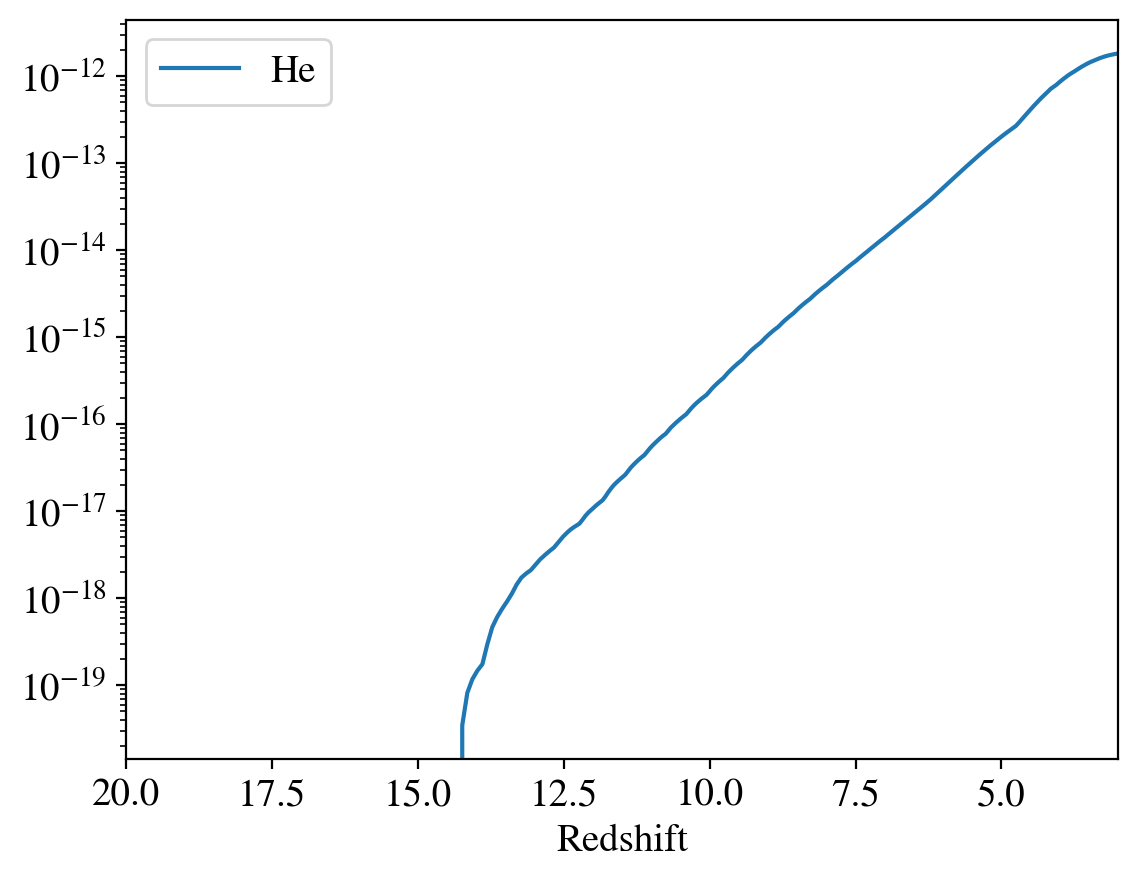

In [33]:
#df_He = pd.read_csv("/orcd/data/mvogelsb/004/chcho/Jalpha_AGN_He_mean.csv")
#df_He["redshift"] = df["redshift"].values[df_He["snap"].values]

plt.plot(df["redshift"], df["J_alpha_AGN_He"], label="He")
#plt.plot(df_He["redshift"], df_He["mean_Jalpha"], label="He")
plt.yscale("log")
plt.xlim(20, 3)
plt.xlabel("Redshift")
plt.legend()
plt.show()

In [27]:
def complete_df(df):
# ---- FIRST CALCULATION BLOCK ----
    funcs = {
        "x_c": x_c,
        #"SFRD": SFRD,
        "S_alpha": S_alpha,
        "tau_GP": tau_GP,
        "x_a": x_a,
        "x_a_He": x_a_He,
        #"x_a_X": x_a_X,
        "J_alpha": J_alpha,
        "J_alpha_He": J_alpha_He,
        "J_alpha_X_He": J_alpha_X_He,
        "J_alpha_AGN": J_alpha_AGN,
        "J_alpha_AGN_He": J_alpha_AGN_He,
        "T_S": T_S,
        "T_S_He": T_S_He,
        "T_b": T_b_PL12,
        "T_b_He": T_b_He,
        "T_b_He_S26": T_b_He_S26,
        "T_b_He_K20": T_b_He_K20,
        "T_b_He_F08": T_b_He_F08,
    }



    z_array = df["redshift"].values
    Nz = len(z_array)
    
    out = {name: np.empty(Nz) for name in funcs}
    
    for i, z in enumerate(z_array):
        for name, func in funcs.items():
            out[name][i] = func(z)

    for name, arr in out.items():
        df[name] = arr
    
    #filename = f"XL_ren5_{px}-{py}-{pz}.csv"
    #df.to_csv(filename, index=False)
    #print(f"Calculation of {px},{py},{pz} is done!")

    return df

In [28]:
metallicity = 1.0e-4
freq, N_nu = get_spec(metallicity)


df = df.sort_values("redshift")
df

funcs = {
    "x_a": x_a,
    "x_c": x_c,
    "x_c_He": x_c_He,
    "x_a_He": x_a_He,
    #"x_a_X": x_a_X,
    "J_alpha": J_alpha,
    "J_alpha_He": J_alpha_He,
    #"J_alpha_X": J_alpha_X,
    #"J_alpha_X_He": J_alpha_X_He,
    "J_alpha_AGN": J_alpha_AGN,
    "J_alpha_AGN_He": J_alpha_AGN_He,
    "T_S": T_S,
    "T_S_He": T_S_He,
    "T_b": T_b_PL12,
    "T_b_He": T_b_He,
    "T_b_He": T_b_He,
    "T_b_He_S26": T_b_He_S26,
    "T_b_He_K20": T_b_He_K20,
    "T_b_He_F08": T_b_He_F08,
}

z_array = df["redshift"].values
Nz = len(z_array)

out = {name: np.empty(Nz) for name in funcs}

for i, z in enumerate(z_array):
    for name, func in funcs.items():
        out[name][i] = func(z)

for name, arr in out.items():
    df[name] = arr


Metallicity index: 1
0.5 4.368563247896207 Myr
0.9 15.666279544247454 Myr
0.99 78.57402523878571 Myr


/tmp/ipykernel_1400870/2330407401.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)
/tmp/ipykernel_1400870/2330407401.py:193: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)


In [72]:
metallicities = [1.0e-05, 1.0e-04, 1.0e-03, 2.0e-03, 3.0e-03, 4.0e-03, 6.0e-03,
                 8.0e-03, 1.0e-02, 1.4e-02, 2.0e-02, 3.0e-02, 4.0e-02]

base_df = df.sort_values("redshift").reset_index(drop=True)

funcs = {
    "x_a": x_a,
    "x_c": x_c,
    "x_c_He": x_c_He,
    "x_a_He": x_a_He,
    "J_alpha": J_alpha,
    "J_alpha_He": J_alpha_He,
    "J_alpha_AGN": J_alpha_AGN,
    "J_alpha_AGN_He": J_alpha_AGN_He,
    "T_S": T_S,
    "T_S_He": T_S_He,
    "T_b": T_b_PL12,
    "T_b_He": T_b_He,
    "T_b_He_S26": T_b_He_S26,
    "T_b_He_K20": T_b_He_K20,
    "T_b_He_F08": T_b_He_F08,
}

z_array = base_df["redshift"].values
Nz = len(z_array)

for metallicity in metallicities:
    freq, N_nu = get_spec(metallicity)

    d = base_df.copy()
    out = {name: np.empty(Nz) for name in funcs}

    for i, z in enumerate(z_array):
        for name, func in funcs.items():
            out[name][i] = func(z)

    for name, arr in out.items():
        d[name] = arr

    fname = f"LUMINA_ALL_Z_{metallicity:.1e}.csv"
    #d.to_csv(fname, index=False)
    print(f"saved {fname}", flush=True)

Metallicity index: 0
0.5 5.5352703459888755 Myr
0.9 31.153521709272596 Myr
0.99 132.9684760980478 Myr


/tmp/ipykernel_2139783/386073299.py:128: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)
/tmp/ipykernel_2139783/386073299.py:202: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I     = np.trapz(integ, zg)


saved LUMINA_ALL_Z_1.0e-05.csv
Metallicity index: 1
0.5 4.368563247896205 Myr
0.9 15.66627954424745 Myr
0.99 78.57402523878571 Myr
saved LUMINA_ALL_Z_1.0e-04.csv
Metallicity index: 2
0.5 3.9058768688663728 Myr
0.9 13.258537797753178 Myr
0.99 82.69337757778406 Myr
saved LUMINA_ALL_Z_1.0e-03.csv
Metallicity index: 3
0.5 3.778367672222674 Myr
0.9 12.262154901242162 Myr
0.99 77.459241718882 Myr
saved LUMINA_ALL_Z_2.0e-03.csv
Metallicity index: 4
0.5 3.7491409843804284 Myr
0.9 11.842898233177719 Myr
0.99 79.8149032380173 Myr
saved LUMINA_ALL_Z_3.0e-03.csv
Metallicity index: 5
0.5 3.8883709839627048 Myr
0.9 11.248080779021729 Myr
0.99 59.12187149760692 Myr
saved LUMINA_ALL_Z_4.0e-03.csv
Metallicity index: 6
0.5 3.753216800590371 Myr
0.9 10.637825862817149 Myr
0.99 53.25020068841957 Myr
saved LUMINA_ALL_Z_6.0e-03.csv
Metallicity index: 7
0.5 3.6431432011577467 Myr
0.9 10.012562259795416 Myr
0.99 54.57774597403029 Myr
saved LUMINA_ALL_Z_8.0e-03.csv
Metallicity index: 8
0.5 3.323884605512593 My

In [73]:
#df["T_S"]

(3.0, 15.0)

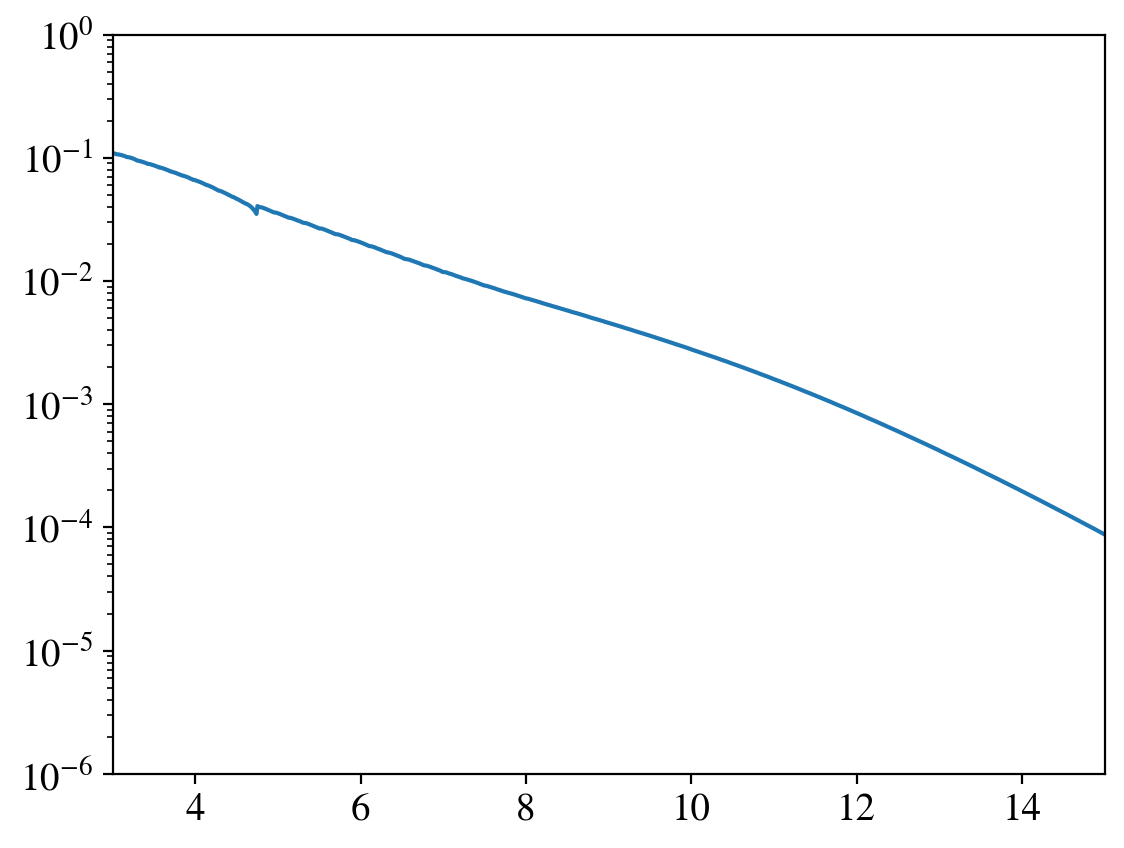

In [74]:
plt.plot(df["redshift"], df["SFRD"]/(6.301081197556214e+25/1.4009476382893126e+73)/(0.78**3.0))
plt.yscale("log")
plt.ylim(1.0e-6,1.0)
plt.xlim(3,15)

In [75]:
df_global["T_S"]

0      3332.171623
1      3329.987344
2      3323.356852
3      3324.231649
4      3319.424344
          ...     
704      72.672075
705      73.497768
706      74.320559
707      75.139657
708      75.954350
Name: T_S, Length: 709, dtype: float64

In [76]:
z_array_snaps = np.array([12.0301395 , 11.21078287, 10.70827338, 10.3558501 , 10.09851182,
        9.84700515,  9.64177554,  9.48039118,  9.36096106,  9.1649276 ,
        9.01077472,  8.67242419,  8.45323452,  8.20378319,  7.99521353,
        7.79137033,  7.62503414,  7.44569698,  7.33351975,  7.20714049,
        7.00584892,  6.86939261,  6.58890794,  6.50242795,  6.34643273,
        6.22121589,  6.09813333,  6.00385467,  5.91082825,  5.83207537,
        5.5010528 ,  4.99986578])

x_a_array_snaps = np.array([  3.10783847,   5.42958705,   7.56569657,   9.41778335,
        10.958993  ,  12.64019464,  14.1466853 ,  15.42089775,
        16.41648424,  18.14953621,  19.60296477,  23.08473167,
        25.57637293,  28.66280082,  31.47575745,  34.4604036 ,
        37.09180911,  40.14886765,  42.66978387,  45.1218292 ,
        49.30365331,  52.80075453,  60.08709382,  62.63035703,
        68.04364691,  72.05094435,  76.97823352,  80.72963903,
        84.66959226,  88.09244345, 104.29382579, 134.2145883 ])

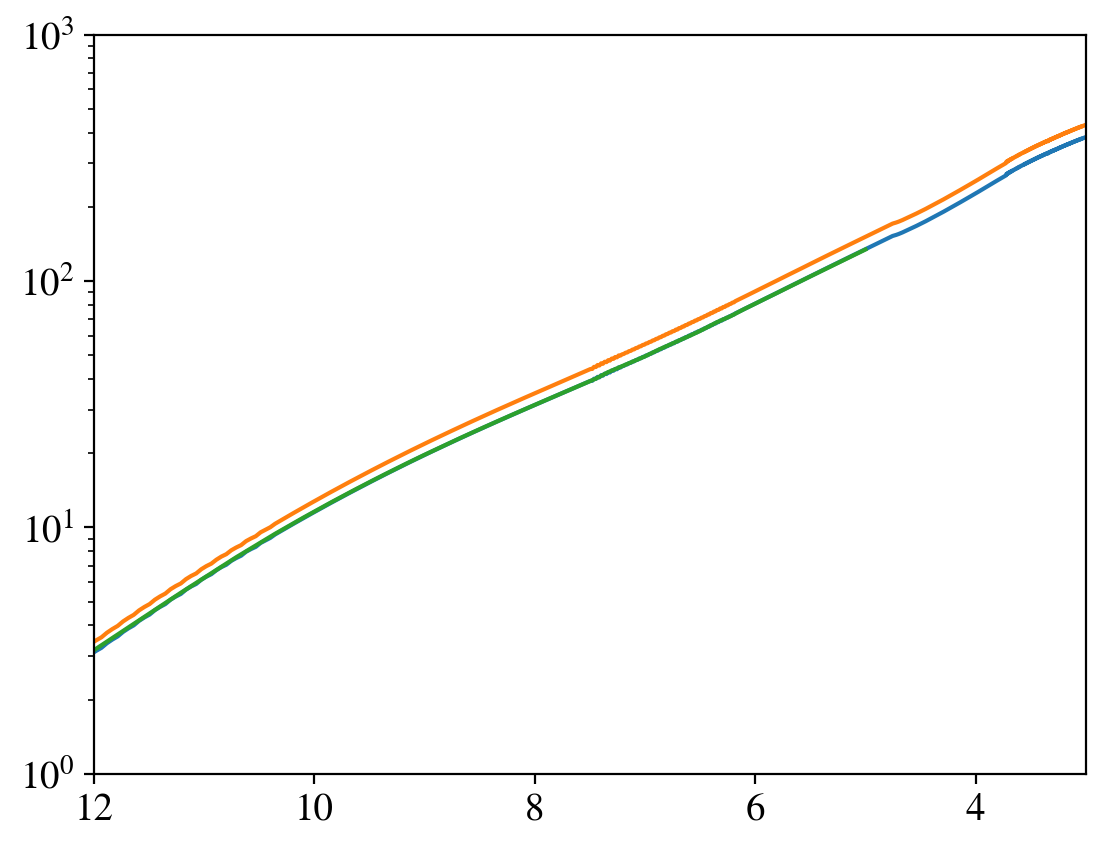

In [77]:
plt.plot(df_global["redshift"], df_global["x_a"])
plt.plot(df["redshift"], df["x_a"])
plt.plot(z_array_snaps, x_a_array_snaps)
plt.xlim(12,3)
plt.ylim(1,1000)
plt.yscale("log")

(30.0, 3.0)

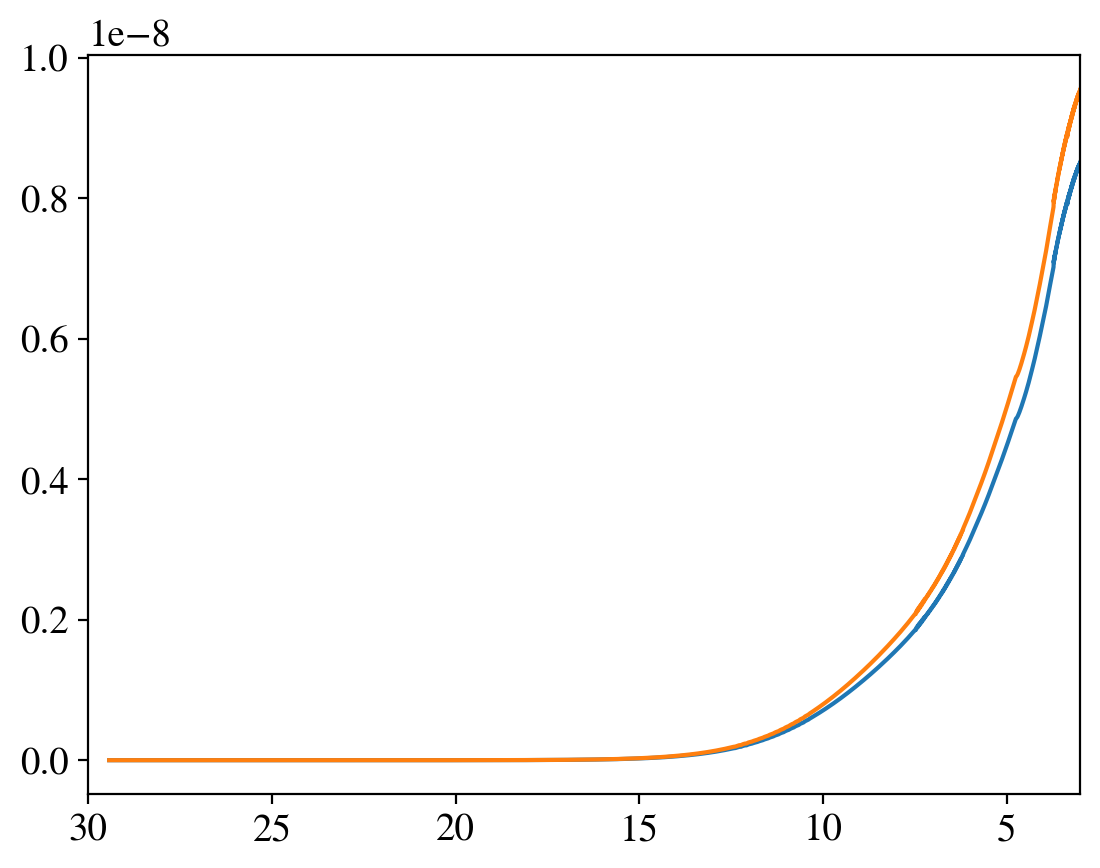

In [78]:
plt.plot(df_global["redshift"], df_global["J_alpha"])
plt.plot(df["redshift"], df["J_alpha"])
plt.xlim(30,3)

In [32]:
plt.plot(df_global["redshift"], df_global["x_c"])
plt.plot(df["redshift"], df["x_c"])
plt.xlim(30,3)

NameError: name 'df_global' is not defined

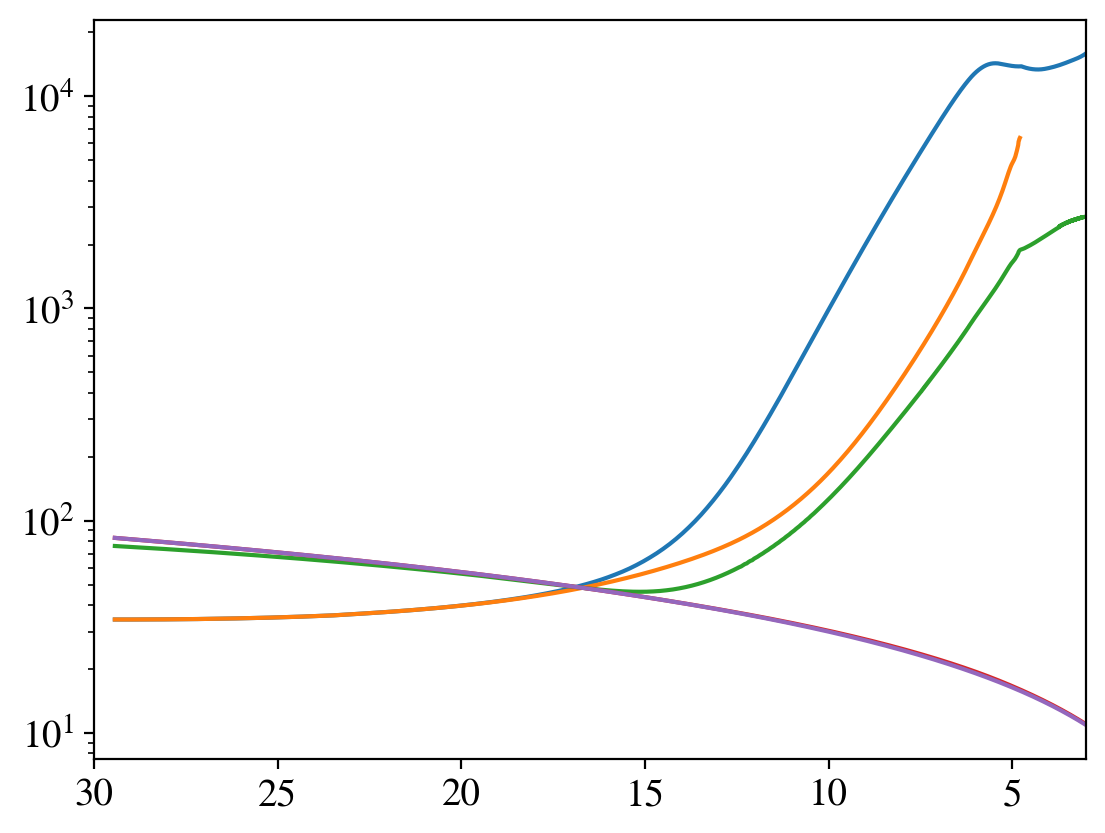

In [31]:
plt.plot(df["redshift"], df["T_vol"])
plt.plot(df["redshift"], df["T_neutral"])
#plt.plot(df_global["redshift"], df_global["T_S"])
plt.plot(df["redshift"], df["T_S"])
plt.plot(df["redshift"], df["T_S_He"])
plt.plot(df["redshift"], df["T_CMB"])
plt.xlim(30,3)
plt.yscale("log")

In [81]:
df["num_He"]/df["num_H"]

0      0.078947
1      0.078947
2      0.078947
3      0.078947
4      0.078947
         ...   
704    0.078947
705    0.078947
706    0.078947
707    0.078947
708    0.078947
Length: 709, dtype: float64

(30.0, 3.0)

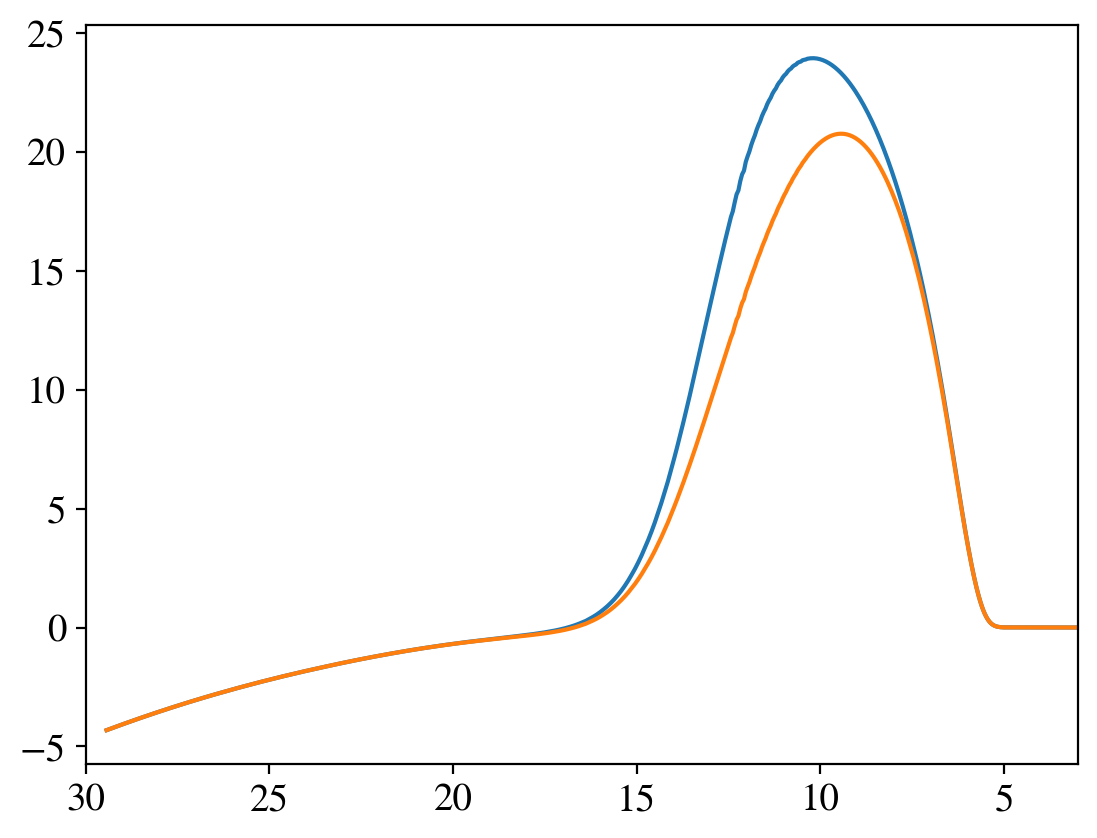

In [82]:
plt.plot(df_global["redshift"], df_global["T_b"])
plt.plot(df["redshift"], df["T_b"])
plt.xlim(30,3)

13 files


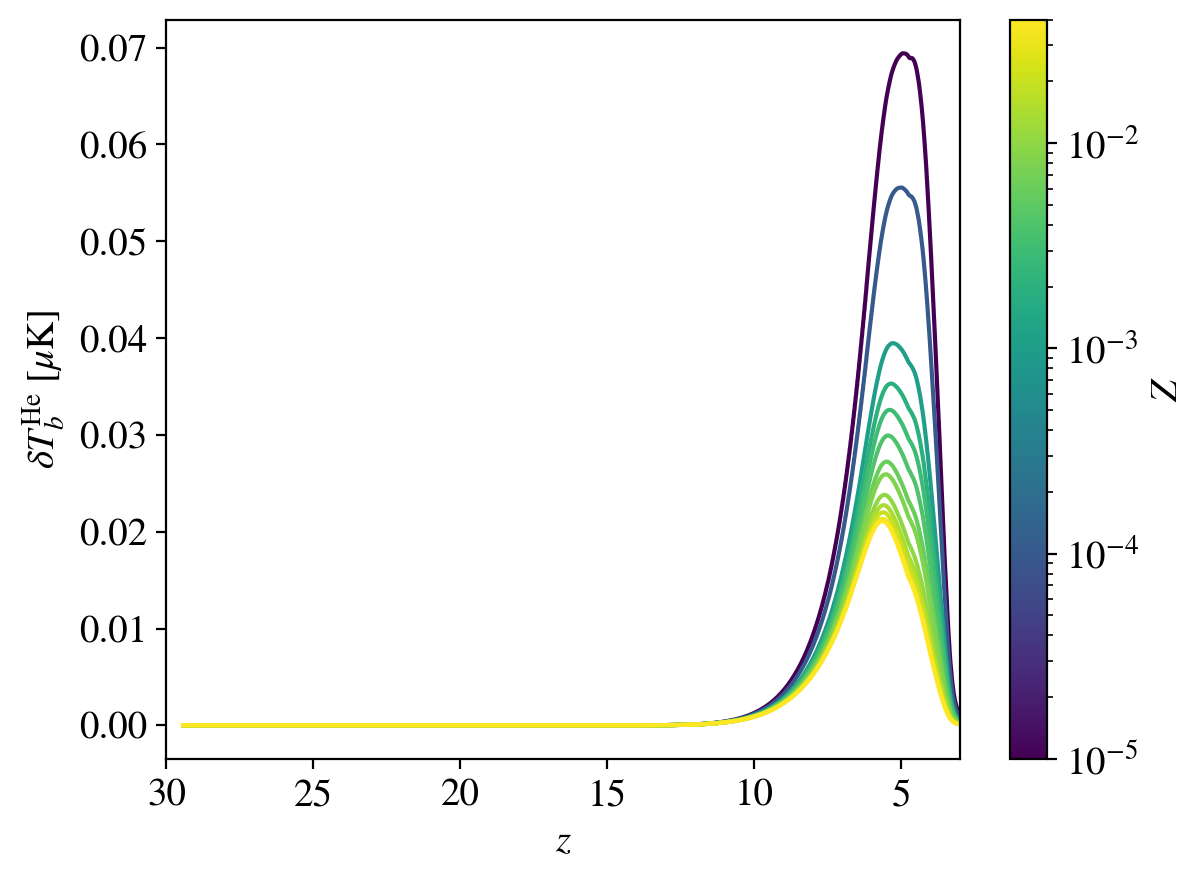

In [83]:
import glob, re
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.colors import LogNorm

files = sorted(
    glob.glob("LUMINA_ALL_Z_*.csv"),
    key=lambda f: float(re.search(r"Z_([\d.e+-]+)\.csv$", f).group(1))
)
print(f"{len(files)} files")

Zs = [float(re.search(r"Z_([\d.e+-]+)\.csv$", f).group(1)) for f in files]
norm = LogNorm(min(Zs), max(Zs))

fig, ax = plt.subplots()
for fname, Z in zip(files, Zs):
    d = pd.read_csv(fname)
    ax.plot(d["redshift"], d["T_b_He"], color=viridis(norm(Z)))

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\delta T^\mathrm{He}_b \ [\mu \mathrm{K} ]$")
ax.set_xlim(30, 3)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=viridis), ax=ax, label="$Z$")
plt.show()

13 files


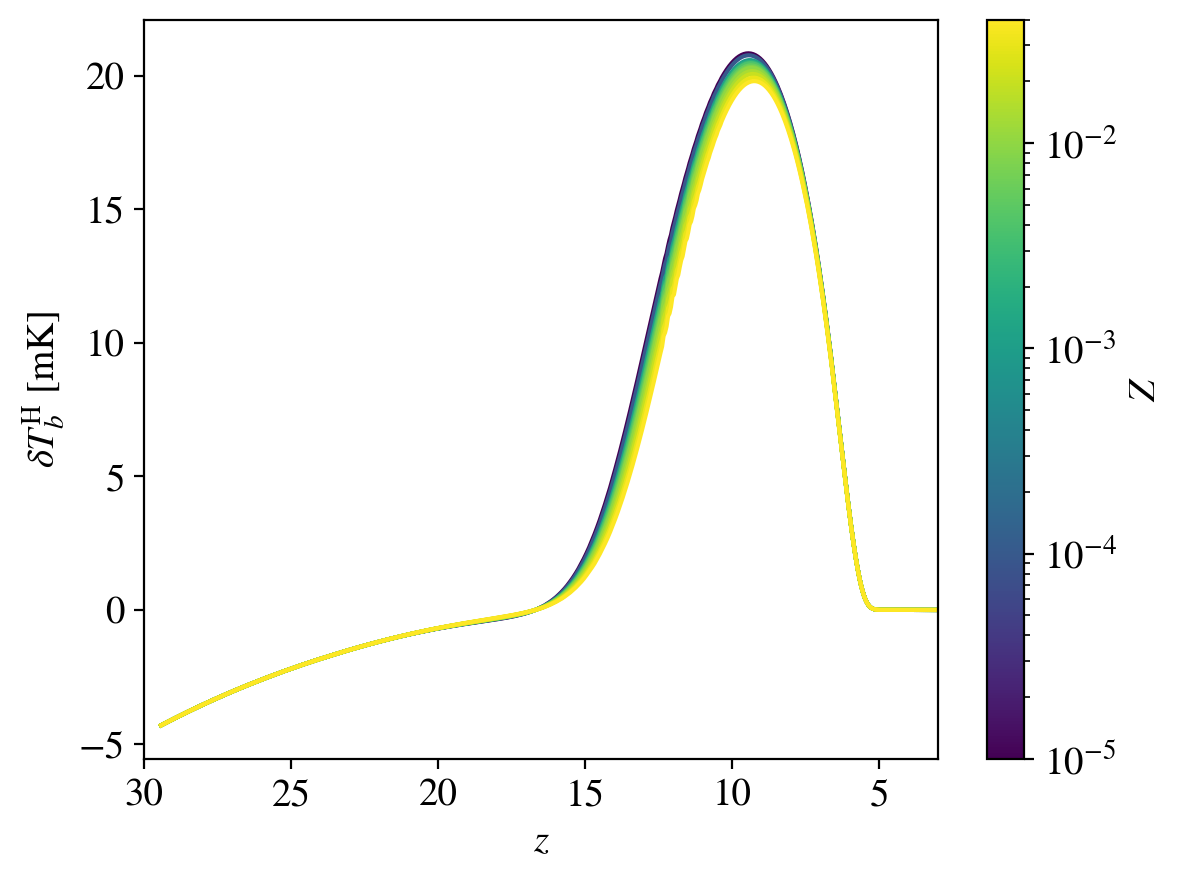

In [84]:
files = sorted(
    glob.glob("LUMINA_ALL_Z_*.csv"),
    key=lambda f: float(re.search(r"Z_([\d.e+-]+)\.csv$", f).group(1))
)
print(f"{len(files)} files")

Zs = [float(re.search(r"Z_([\d.e+-]+)\.csv$", f).group(1)) for f in files]
norm = LogNorm(min(Zs), max(Zs))

fig, ax = plt.subplots()
for fname, Z in zip(files, Zs):
    d = pd.read_csv(fname)
    ax.plot(d["redshift"], d["T_b"], color=viridis(norm(Z)))

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\delta T^\mathrm{H}_b \ [ \mathrm{mK} ]$")
ax.set_xlim(30, 3)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=viridis), ax=ax, label="$Z$")
plt.show()

(30.0, 3.0)

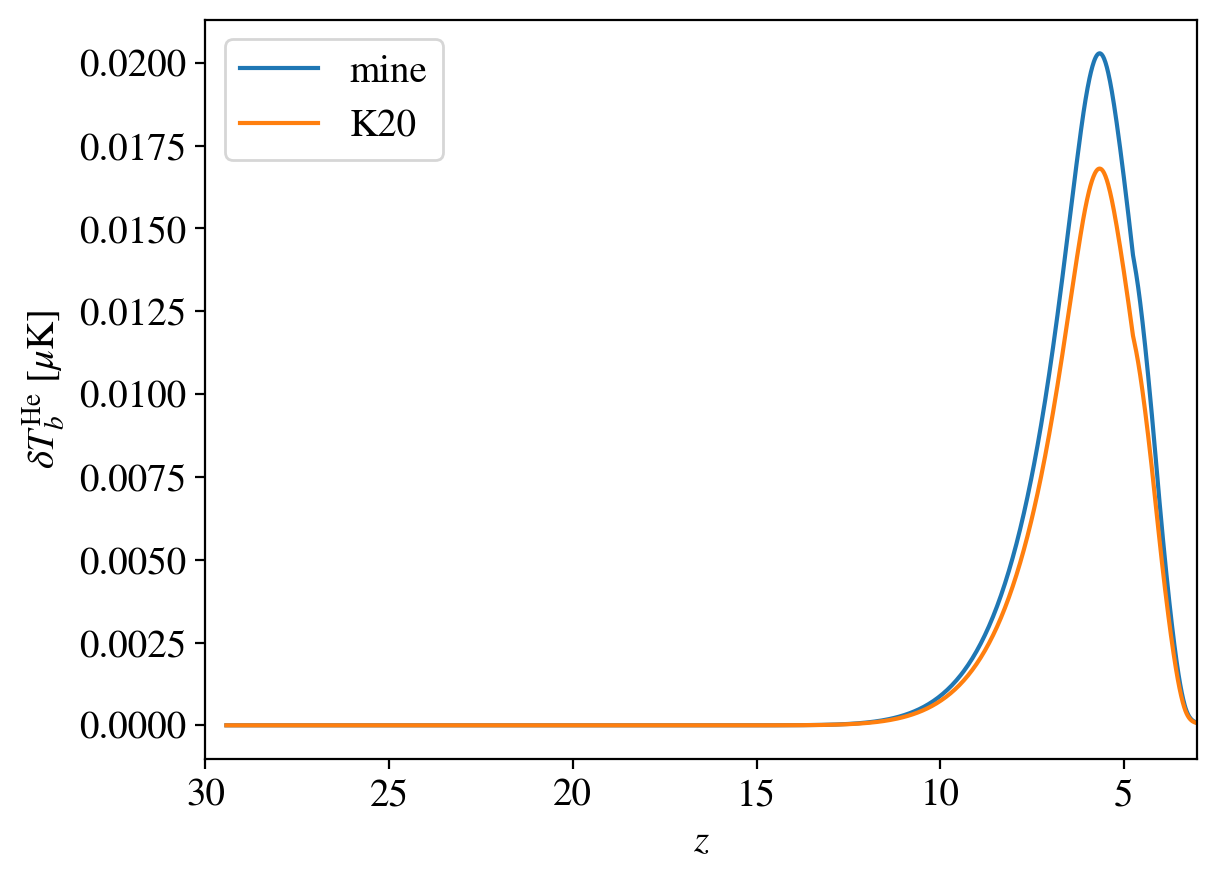

In [30]:
#plt.plot(df_global["redshift"], df_global["T_b_He"])
plt.plot(df["redshift"], df["T_b_He"], label="mine")
#plt.plot(df["redshift"], df["T_b_He_S26"], label="S26")
plt.plot(df["redshift"], df["T_b_He_K20"], label="K20")
#plt.plot(df["redshift"], df["T_b_He_F08"], label="F08")

#plt.scatter(7.99,2.8447e-02, s=50, label="test")
#plt.scatter(6.0039, 0.0517444734, s=50, label="test")
#plt.scatter(4.5162, 0.04839500321, s=50, label="test")
#plt.scatter(4.4952,0.04801584346, s=50, label="test")
plt.xlabel(r"$z$")
plt.ylabel(r"$\delta T^\mathrm{He}_b \ [\mu \mathrm{K} ]$")


plt.legend()
plt.xlim(30,3)

In [34]:
df.to_csv("only_AGN.csv", index=False)

In [43]:
df_global.iloc[176]

snapshot          5.320000e+02
redshift          3.720955e+00
f_HII             9.999710e-01
f_HeII            2.808719e-01
f_HeIII           5.677249e-02
T_vol             1.401456e+04
SFRD              1.643057e-49
Density           1.355889e-09
LuminosityAGN     1.569694e+41
H_cgm             1.264873e-17
H(z)              3.902724e+02
T_CMB             1.286696e+01
rho_H             3.360270e-29
num_H             2.007570e-05
frac_HI           2.900321e-05
num_HI            5.822596e-10
num_HII           2.007511e-05
num_He            1.584923e-06
num_HeII          4.451605e-07
num_HeIII         1.139747e-06
num_HeI           1.565435e-11
num_p             2.007511e-05
num_e             2.279977e-05
J_alpha_AGN       2.515121e-20
J_alpha_AGN_He    1.363472e-11
x_a               2.718638e+02
x_c               4.241981e-01
x_c_He            9.168835e-03
x_a_He            7.735372e-02
x_a_X             3.455207e-02
J_alpha           7.113688e-09
J_alpha_He        7.602616e-11
J_alpha_

In [44]:
df["num_He"]*1.0e-4/df["num_H"]

0      0.000008
1      0.000008
2      0.000008
3      0.000008
4      0.000008
         ...   
704    0.000008
705    0.000008
706    0.000008
707    0.000008
708    0.000008
Length: 709, dtype: float64

In [45]:
df_g = pd.read_csv("/orcd/data/mvogelsb/004/chcho/mean_SFR_history.csv")


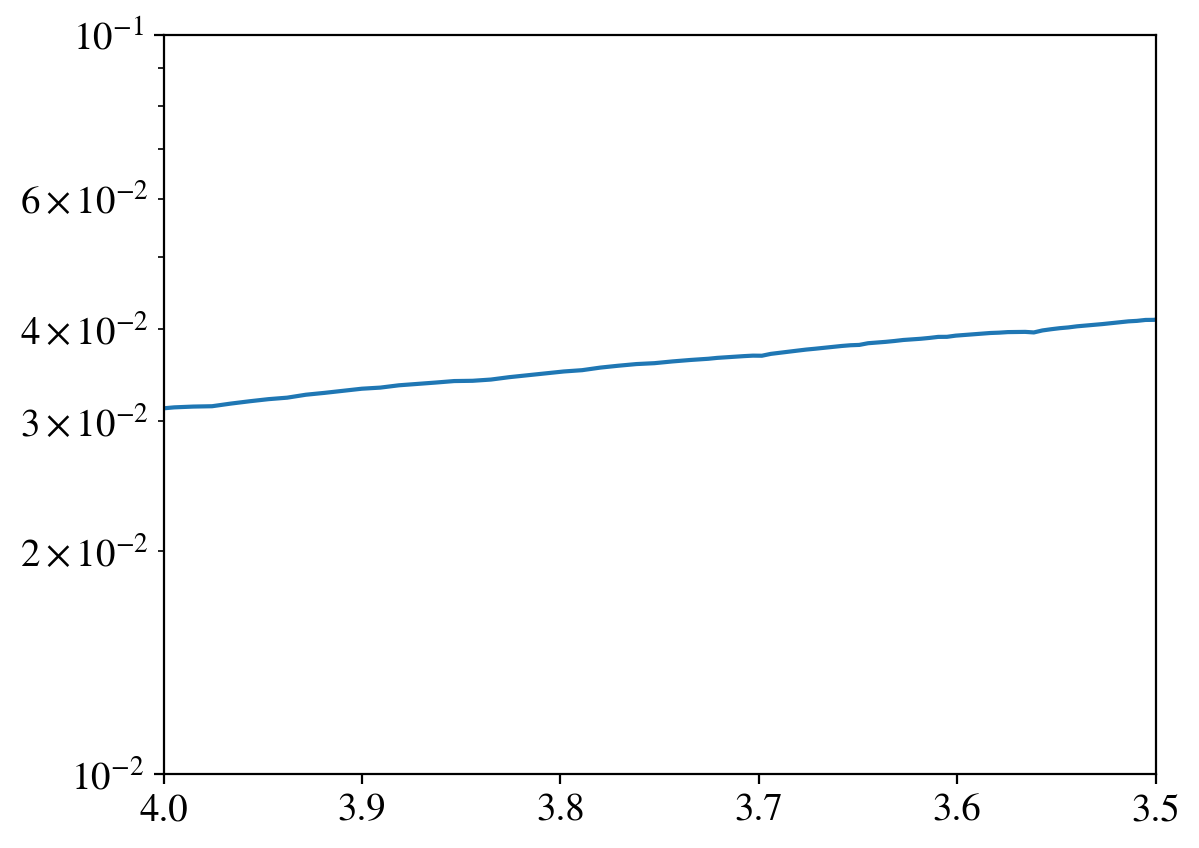

In [46]:
plt.plot(df_g["redshift"], df_g["mean_SFR"])#*6.301081197556214e+25/1.4009476382893126e+73)
#plt.plot(df["redshift"], df["SFRD"])
plt.xlim(4,3.5)
plt.ylim(1.0e-2,1.0e-1)
plt.yscale("log")

Text(0, 0.5, '$J_\\alpha\\;[\\mathrm{cm^{-2}\\,s^{-1}\\,Hz^{-1}\\,sr^{-1}}]$')

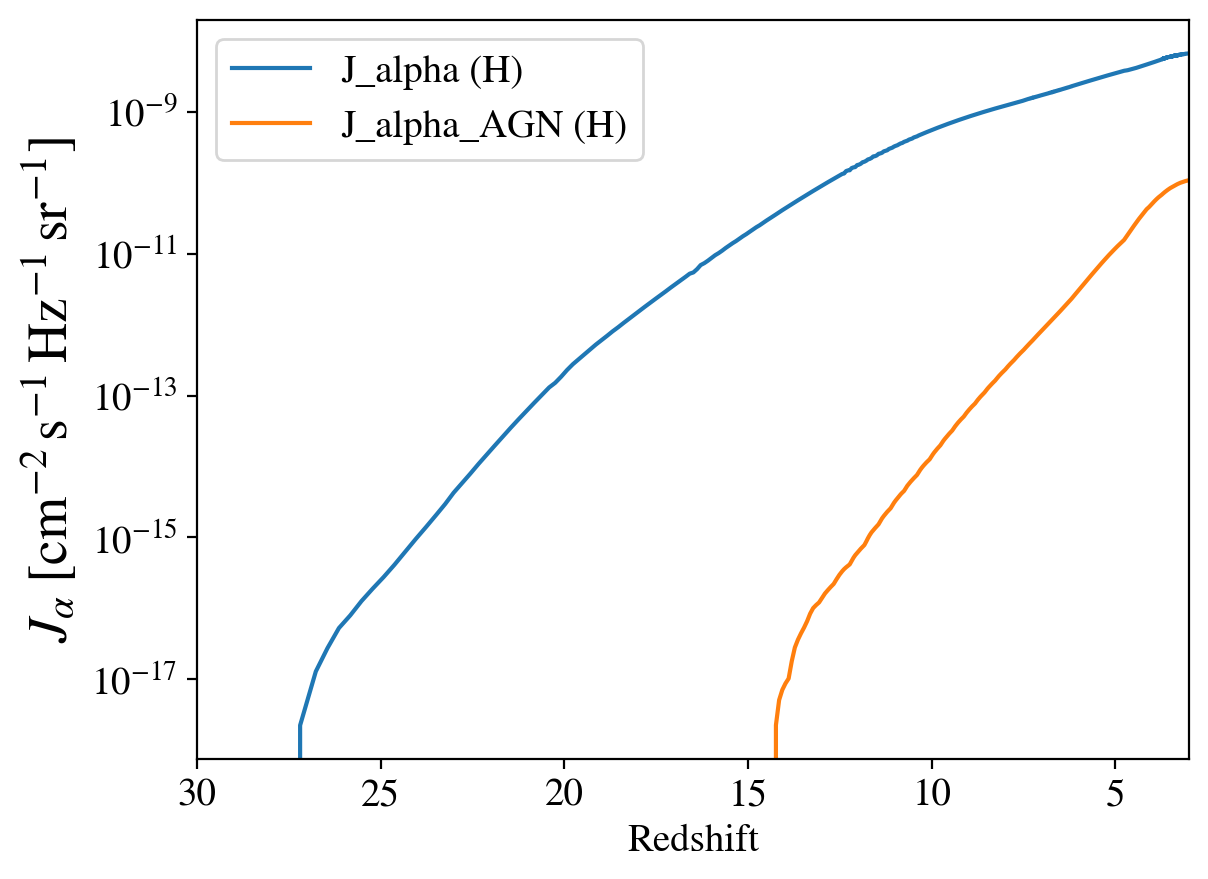

In [17]:
df = pd.read_csv("/orcd/data/mvogelsb/004/chcho/LUMINA_ALL_Z_1.0e-02.csv")


plt.plot(df["redshift"], df["J_alpha"], label="J_alpha (H)")
#plt.plot(df["redshift"], df["J_alpha_He"], label="J_alpha_He (Total)")
#plt.plot(df["redshift"], df["J_alpha_X"], label="J_alpha_X")
#plt.plot(df["redshift"], df["J_alpha_X_He"], label="J_alpha_X (He)")
plt.plot(df["redshift"], df["J_alpha_AGN"], label="J_alpha_AGN (H)")
#plt.plot(df["redshift"], df["J_alpha_He"]-df["J_alpha_AGN_He"], label="J_alpha_Star")
#plt.plot(df["redshift"], df["J_alpha_AGN_He"], label="J_alpha_AGN")

#df["J_alpha_AGN_He"]
plt.legend()
plt.xlim(30,3)
plt.yscale("log")
plt.xlabel("Redshift")
plt.ylabel(r"$J_\alpha\;[\mathrm{cm^{-2}\,s^{-1}\,Hz^{-1}\,sr^{-1}}]$", fontsize=20)


In [65]:
PLANCK = 6.62607015e-27
NU_LL_HEII = 1.31583e16                    # matches your C code
H_NU_HEII_LYA = PLANCK * NU_LL_HEII * (1 - 1/4)
H_NU_HEII_LYA

6.539086414105875e-11

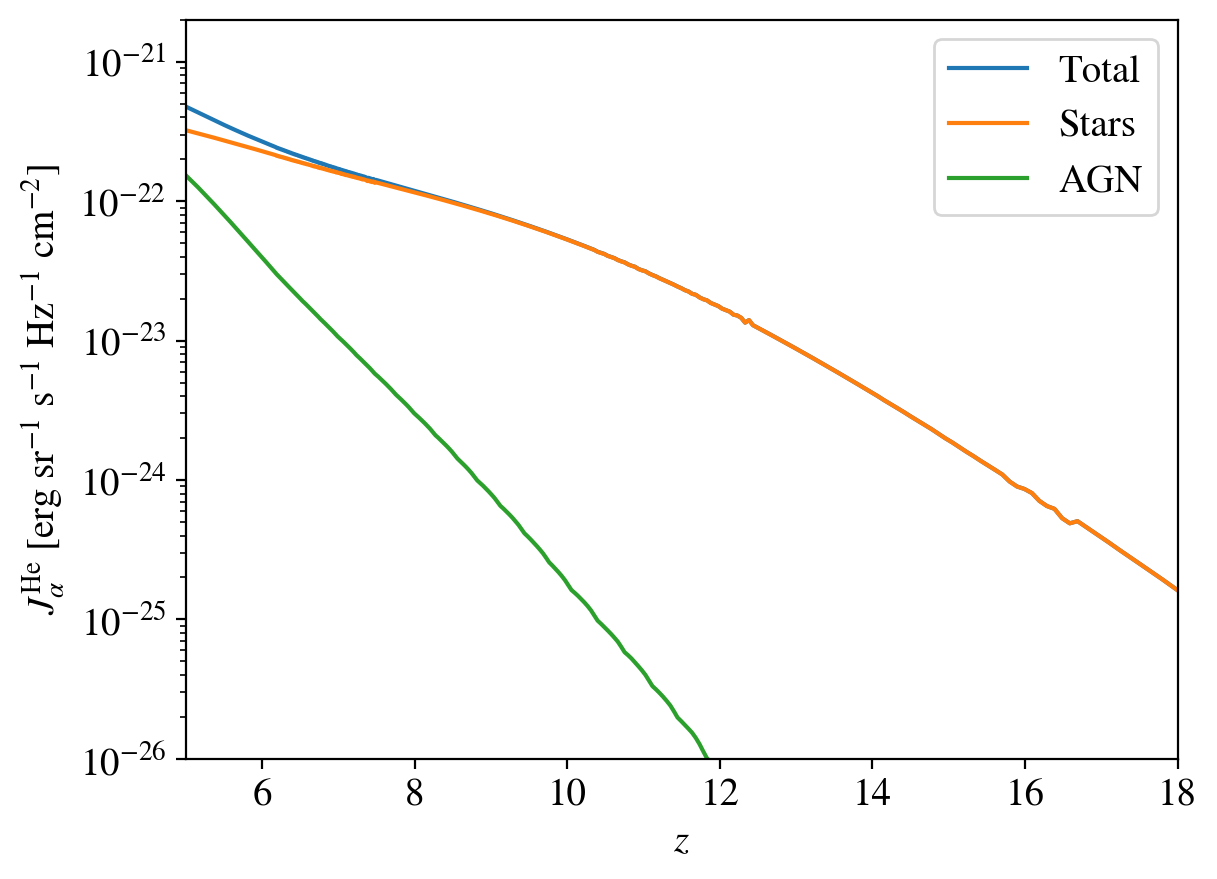

In [63]:
H_NU_HEII_LYA = 6.5395e-11      # erg

plt.plot(df["redshift"], df["J_alpha_He"]     * H_NU_HEII_LYA, label="Total")
plt.plot(df["redshift"], (df["J_alpha_He"]-df["J_alpha_AGN_He"])   * H_NU_HEII_LYA, label="Stars")
plt.plot(df["redshift"], df["J_alpha_AGN_He"]    * H_NU_HEII_LYA, label="AGN")
plt.yscale("log")
plt.xlabel(r"$z$")
plt.ylabel(r"$J_\alpha^{\rm He}\ [\mathrm{erg\ sr^{-1}\ s^{-1}\ Hz^{-1}\ cm^{-2}}]$")
plt.xlim(5, 18)
plt.ylim(1.0e-26, 2.0e-21)
plt.legend()

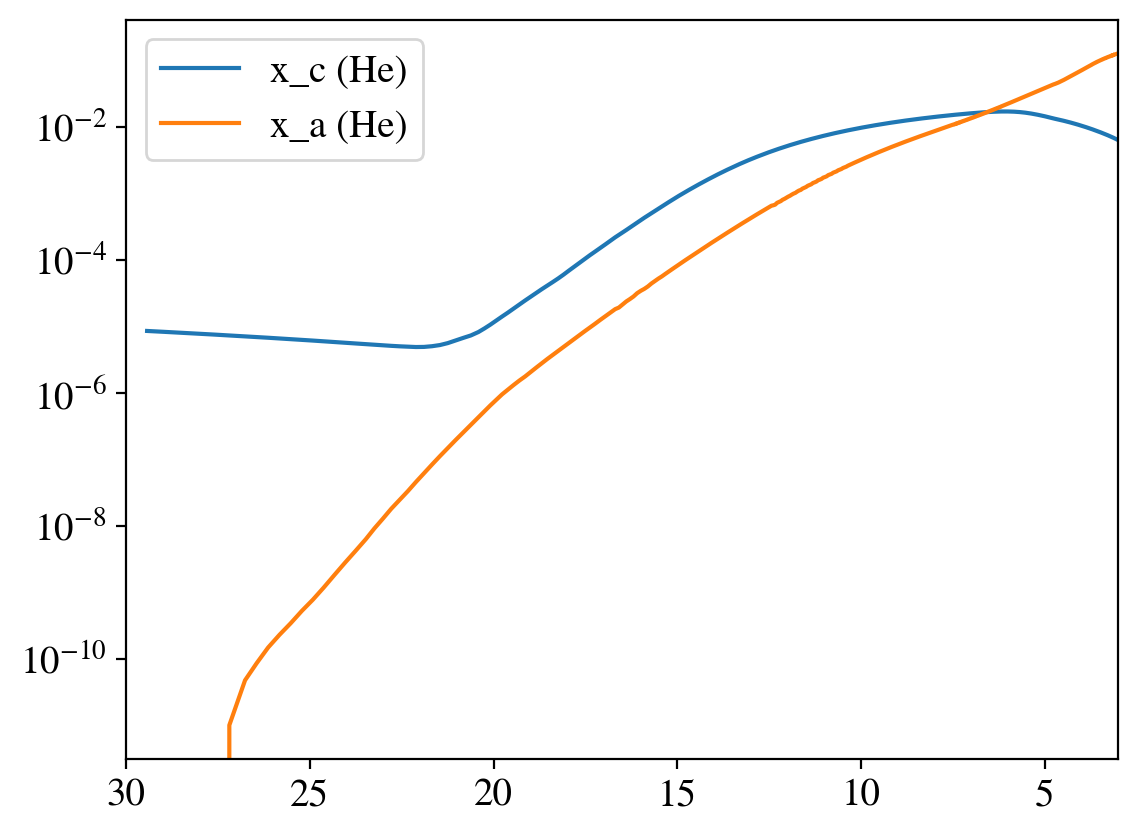

In [48]:
plt.plot(df["redshift"], df["x_c_He"], label="x_c (He)")
plt.plot(df["redshift"], df["x_a_He"], label="x_a (He)")
#plt.plot(df["redshift"], df["x_a_X"], label="x_a X)")
plt.legend()
plt.xlim(30,3)
plt.yscale("log")



(3.0, 5.0)

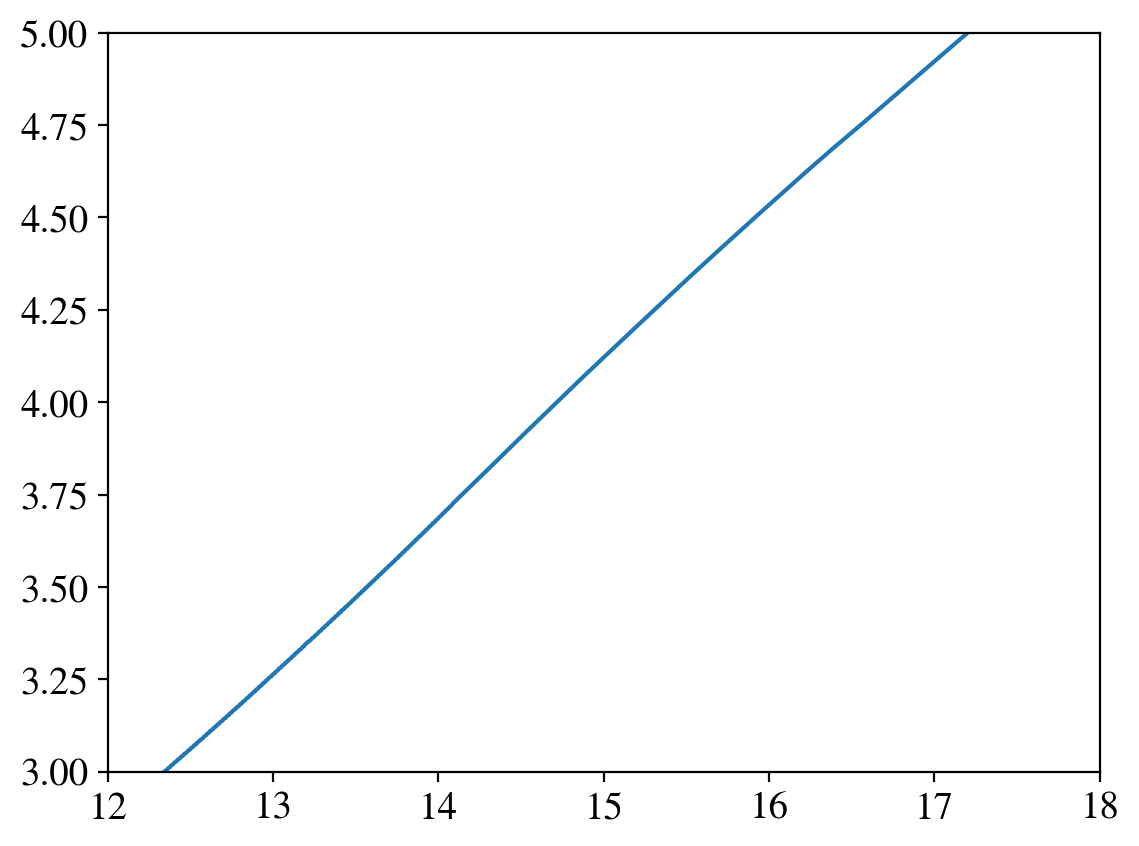

In [49]:
#plt.plot(df_global["redshift"], df_global["T_S"])
plt.plot(df["T_S_He"], df["redshift"])
plt.xlim(12, 18)
plt.ylim(3, 5)
#35 #plt.xlim(30,3)


In [48]:
MPC_CM = 3.085677581e24  # cm per Mpc

SFRD_CONV = YR / M_SOL   # g/s/cm^3 -> M_sun/yr/cm^3,  ~ 1.587e-26

def L_ISM(z):
    """erg/s/cm^3"""
    return 3.3e40 * SFRD(z) * SFRD_CONV
    
def L_HMXB(z, Z):
    """erg/s/cm^3"""
    beta = np.array([
        4.0431737e+01,  1.3511736e+02, -1.0627360e+05,
        2.5606802e+07, -3.0811049e+09,  2.0496541e+11,
       -7.6798616e+12,  1.5199552e+14, -1.2367941e+15,
    ])
    Z = np.asarray(Z, dtype=float)
    logL_per_SFR = sum(b * Z**i for i, b in enumerate(beta))
    return 10.0**logL_per_SFR * SFRD(z) * SFRD_CONV


def epsilon_X_alpha(z):
    Z = 1.0e-4
    return L_ISM(z) + L_HMXB(z, Z)

In [49]:
SFRD(12)

np.float64(1.8138317669919852e-51)

In [47]:
L_ISM(12) + L_HMXB(12, 1.0e-4)

np.float64(1.7508640259838263e-36)

In [48]:
J_alpha_star(12,4)

np.float64(7.903654120866772e-12)

In [49]:
df["J_alpha"]

708    8.530468e-09
707    8.525769e-09
706    8.506620e-09
705    8.511818e-09
704    8.498548e-09
           ...     
4      0.000000e+00
3      0.000000e+00
2      0.000000e+00
1      0.000000e+00
0      0.000000e+00
Name: J_alpha, Length: 709, dtype: float64

In [50]:
df["J_alpha_X"]

708    1.361327e-12
707    1.357134e-12
706    1.352806e-12
705    1.347590e-12
704    1.346174e-12
           ...     
4      0.000000e+00
3      0.000000e+00
2      0.000000e+00
1      0.000000e+00
0      0.000000e+00
Name: J_alpha_X, Length: 709, dtype: float64

In [58]:
df.to_csv("LUMINA_all.csv", index=False)

In [52]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

# =============================================================================
# 1. CONSTANTS
# =============================================================================
c_cms     = 2.998e10          # cm/s
h_erg     = 6.62607e-27       # erg*s
h_eV      = 4.13607e-15       # eV*s
hc_eVA    = 12398.42          # eV*Angstrom
c_cgs_A   = 2.998e18          # Angstrom/s
nu_alpha  = 2.466e15          # Hz (Ly-alpha)
H0_cgs    = 67.74 * 1e5 / 3.086e24   # s^-1
Omega_m   = 0.3089
Omega_L   = 0.6911
box_cMpc  = 500.0             # cMpc, hardcoded

# =============================================================================
# 2. UNIT CONVERSION FOR LuminosityAGN CODE UNITS -> erg/s
# =============================================================================
h_cosmo        = 0.6774
UnitMass_g     = 1.989e33 * 1e10 / h_cosmo
UnitVel_cms    = 1e5
UnitLen_cm     = 3.086e21 / h_cosmo
UnitTime_s     = UnitLen_cm / UnitVel_cms
UNIT_LUMINOSITY = UnitMass_g * UnitVel_cms**2 / UnitTime_s
print(f"1 code unit = {UNIT_LUMINOSITY:.4e} erg/s")

# =============================================================================
# 3. LOAD AND NORMALIZE SHEN+2020 SED
# =============================================================================
data      = np.genfromtxt("AGN_SED.dat", comments="#")
lam       = data[:, 0]          # Angstrom (linear)
log_nuLnu = data[:, 1]          # log10(nu L_nu) [erg/s]
nuLnu     = 10**log_nuLnu

# Sort ascending lambda
idx   = np.argsort(lam)
lam   = lam[idx]
nuLnu = nuLnu[idx]

# Convert to L_nu, sort ascending nu
nu       = c_cgs_A / lam        # Hz
L_nu_ref = nuLnu / nu           # erg/s/Hz

idx_nu   = np.argsort(nu)
nu_sort  = nu[idx_nu]
Lnu_sort = L_nu_ref[idx_nu]

# Normalize: int L_nu dnu = 1
norm     = trapezoid(Lnu_sort, nu_sort)
Lnu_norm = Lnu_sort / norm      # Hz^-1

# =============================================================================
# 4. BUILD dL/dE AND dN/dE AT REFERENCE L_total = 1e46 erg/s
# =============================================================================
ref_L    = 1.0e46
L_nu_vox = ref_L * Lnu_norm     # erg/s/Hz
E_eV     = h_eV * nu_sort       # eV

dLdE_vox  = L_nu_vox / h_eV                  # erg/s/eV
dNdnu_vox = L_nu_vox / (h_erg * nu_sort)     # photons/s/Hz
dNdE_vox  = dNdnu_vox / h_eV                 # photons/s/eV

# Verify consistency
L_check  = trapezoid(L_nu_vox,  nu_sort)
Ndot_nu  = trapezoid(dNdnu_vox, nu_sort)
Ndot_E   = trapezoid(dNdE_vox,  E_eV)
print(f"int L_nu dnu   = {L_check:.4e} erg/s  (should be {ref_L:.4e})")
print(f"int dN/dnu dnu = {Ndot_nu:.4e} photons/s")
print(f"int dN/dE dE   = {Ndot_E:.4e} photons/s  (should match above)")

# Fine interpolation grid
interp_dLdE = interp1d(np.log10(E_eV), np.log10(dLdE_vox),
                        kind="linear", fill_value="extrapolate")
interp_dNdE = interp1d(np.log10(E_eV), np.log10(dNdE_vox),
                        kind="linear", fill_value="extrapolate")

E_fine    = np.logspace(np.log10(E_eV.min()), np.log10(E_eV.max()), 100000)
dLdE_fine = 10**interp_dLdE(np.log10(E_fine))
dNdE_fine = 10**interp_dNdE(np.log10(E_fine))

def band_integral(E_arr, y_arr, E_lo, E_hi):
    mask = (E_arr >= E_lo) & (E_arr <= E_hi)
    if mask.sum() < 2:
        return 0.0
    return trapezoid(y_arr[mask], E_arr[mask])

# =============================================================================
# 5. SCALE-FREE SED FRACTION FOR LY-ALPHA BAND
# =============================================================================
f_N_alpha = band_integral(E_fine, dNdE_fine, 10.15, 10.25) / ref_L
print(f"f_N_alpha = {f_N_alpha:.4e} photons/s/(erg/s)")

# =============================================================================
# 6. J_alpha,X FUNCTION
# =============================================================================
def J_alpha_AGN(L_erg, z):
    """
    Compute J_alpha,X from AGN for a single snapshot.

    Parameters
    ----------
    L_erg : float   Total AGN luminosity in the box [erg/s]
    z     : float   Redshift

    Returns
    -------
    J_alpha_X : float   [erg/s/cm^2/Hz/sr]
    """
    Hz    = H0_cgs * np.sqrt(Omega_m * (1+z)**3 + Omega_L)
    dx_cm = box_cMpc * 3.086e24 / (1 + z)
    V_box = dx_cm**3
    ndot  = f_N_alpha * L_erg / V_box
    return (c_cms / (4 * np.pi)) * ndot / (Hz * nu_alpha)

# =============================================================================
# 7. APPLY TO DATAFRAME
# =============================================================================
# df must have columns: "LuminosityAGN" [erg/s], "redshift"

df["J_alpha_AGN"] = df.apply(
    lambda row: J_alpha_AGN(row["LuminosityAGN"], row["redshift"]), axis=1
)

print(df[["redshift", "LuminosityAGN", "J_alpha_AGN"]])

1 code unit = 6.4452e+36 erg/s
int L_nu dnu   = 1.0000e+46 erg/s  (should be 1.0000e+46)
int dN/dnu dnu = 1.2938e+58 photons/s
int dN/dE dE   = 1.2938e+58 photons/s  (should match above)
f_N_alpha = 7.3130e+07 photons/s/(erg/s)
      redshift  LuminosityAGN   J_alpha_AGN
708   2.986690   2.461625e+41  3.039999e-20
707   2.990499   2.440882e+41  3.018851e-20
706   2.994312   2.423761e+41  3.002120e-20
705   2.998129   2.468312e+41  3.061833e-20
704   3.001949   2.460633e+41  3.056832e-20
..         ...            ...           ...
4    27.624245   0.000000e+00  0.000000e+00
3    28.065021   0.000000e+00  0.000000e+00
2    28.512585   0.000000e+00  0.000000e+00
1    28.967040   0.000000e+00  0.000000e+00
0    29.428494   0.000000e+00  0.000000e+00

[709 rows x 3 columns]


In [53]:
df

,snapshot,redshift,f_HII,f_HeII,f_HeIII,T_vol,SFRD,Density,LuminosityAGN,H_cgm,...,J_alpha_He,J_alpha_X,J_alpha_X_He,T_S,T_S_He,T_b,T_b_He,T_b_He_S26,T_b_He_K20,T_b_He_F08
708,708,2.986690,9.999865e-01,0.008392,7.828438e-02,15954.335393,2.353998e-49,1.348938e-09,2.461625e+41,9.882956e-18,...,9.605241e-11,1.361327e-12,8.500151e-14,3332.171623,12.189706,0.000230,9.587173e-04,1.866754e-03,7.942552e-04,9.646276e-04
707,707,2.990499,9.999864e-01,0.008496,7.827620e-02,15937.080869,2.349996e-49,1.348988e-09,2.440882e+41,9.896641e-18,...,9.599148e-11,1.357134e-12,8.473965e-14,3329.987344,12.199522,0.000231,9.698234e-04,1.888471e-03,8.034561e-04,9.758021e-04
706,706,2.994312,9.999864e-01,0.008603,7.826779e-02,15919.914658,2.345747e-49,1.349038e-09,2.423761e+41,9.910347e-18,...,9.569981e-11,1.352806e-12,8.446944e-14,3323.356852,12.206330,0.000232,9.792384e-04,1.906897e-03,8.112561e-04,9.852751e-04
705,705,2.998129,9.999863e-01,0.008712,7.825916e-02,15902.907694,2.339940e-49,1.349044e-09,2.468312e+41,9.924074e-18,...,9.588099e-11,1.347590e-12,8.414375e-14,3324.231649,12.219331,0.000232,9.930599e-04,1.933905e-03,8.227066e-04,9.991818e-04
704,704,3.001949,9.999862e-01,0.008824,7.825028e-02,15886.018519,2.340718e-49,1.349134e-09,2.460633e+41,9.937821e-18,...,9.559383e-11,1.346174e-12,8.405530e-14,3319.424344,12.226221,0.000234,1.003112e-03,1.953574e-03,8.310341e-04,1.009296e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,4,27.624245,9.995329e-07,0.000001,7.864623e-08,34.310645,0.000000e+00,1.364558e-09,0.000000e+00,1.868766e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,72.672075,78.014639,-3.350141,-2.687427e-11,-5.323790e-11,-2.226415e-11,-2.703994e-11
3,3,28.065021,9.995460e-07,0.000001,7.865462e-08,34.259699,0.000000e+00,1.364558e-09,0.000000e+00,1.912093e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,73.497768,79.215916,-3.572572,-2.878280e-11,-5.701881e-11,-2.384528e-11,-2.896023e-11
2,2,28.512585,9.995593e-07,0.000001,7.866312e-08,34.224915,0.000000e+00,1.364558e-09,0.000000e+00,1.956424e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,74.320559,80.435688,-3.807283,-3.078275e-11,-6.098086e-11,-2.550216e-11,-3.097252e-11
1,1,28.967040,9.995724e-07,0.000001,7.867173e-08,34.205899,0.000000e+00,1.364558e-09,0.000000e+00,2.001783e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,75.139657,81.674240,-4.054954,-3.287676e-11,-6.512923e-11,-2.723696e-11,-3.307944e-11


In [55]:
J_alpha_AGN_total(3)

NameError: name 'J_alpha_AGN_total' is not defined

In [ ]:
df["J_alpha_AGN"]

In [193]:
1.982233e-10/2.155457e-11

9.19634676080293

In [194]:
+2.944639e-09/1.082605e-10

27.199569556763546

In [195]:
+2.014270e-10/2.161293e-11

9.319745171061953

In [196]:
fH  = band_frac(10.2, 13.6)
fHe = band_frac_He()
print(f"1/f_H  = {1/fH:.1f}   (C/Python ratio for H,  expect ~27)")
print(f"1/f_He = {1/fHe:.1f}   (C/Python ratio for He, expect ~9)")
print(f"f_He/f_H = {fHe/fH:.2f}   (expect ~3)")

1/f_H  = 29.2   (C/Python ratio for H,  expect ~27)
1/f_He = inf   (C/Python ratio for He, expect ~9)
f_He/f_H = 0.00   (expect ~3)


/tmp/ipykernel_1258481/3040008859.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(L_nu[m], nu_sed[m]) / L_bol
/tmp/ipykernel_1258481/3040008859.py:160: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L_bol_local = np.trapz((Ntilde_nu*PLANCK*nu_sed)*1.0, nu_sed)  # = 1 by constr.
/tmp/ipykernel_1258481/3040008859.py:163: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(phi[m], nu_sed[m])
/tmp/ipykernel_1258481/3470825073.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"1/f_He = {1/fHe:.1f}   (C/Python ratio for He, expect ~9)")


In [197]:
fH  = band_frac(10.2, 13.6)     # H Lyman band fraction
fHe = band_frac_He()            # He Lyman band fraction
print(f"H  correction = {fH:.6e}   (1/fH  = {1/fH:.4f})")
print(f"He correction = {fHe:.6e}   (1/fHe = {1/fHe:.4f})")

H  correction = 3.428638e-02   (1/fH  = 29.1661)
He correction = 0.000000e+00   (1/fHe = inf)


/tmp/ipykernel_1258481/3040008859.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(L_nu[m], nu_sed[m]) / L_bol
/tmp/ipykernel_1258481/3040008859.py:160: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L_bol_local = np.trapz((Ntilde_nu*PLANCK*nu_sed)*1.0, nu_sed)  # = 1 by constr.
/tmp/ipykernel_1258481/3040008859.py:163: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(phi[m], nu_sed[m])
/tmp/ipykernel_1258481/284360864.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"He correction = {fHe:.6e}   (1/fHe = {1/fHe:.4f})")


In [198]:
import h5py, glob

for path in glob.glob(".../Jalpha_AGN_H_*.hdf5"):
    with h5py.File(path, "r+") as f:
        d = f["Jalpha_AGN_H"]
        d[...] = d[...] * fH                      # in-place rescale
        # also fix the stored scalars if you rely on them
        if "Header" in f:
            for key in ("J_mean", "J_scalar"):
                if key in f["Header"].attrs:
                    f["Header"].attrs[key] = f["Header"].attrs[key] * fH

for path in glob.glob(".../Jalpha_AGN_He_*.hdf5"):
    with h5py.File(path, "r+") as f:
        d = f["Jalpha_AGN_He"]
        d[...] = d[...] * fHe
        if "Header" in f:
            for key in ("J_mean", "J_scalar"):
                if key in f["Header"].attrs:
                    f["Header"].attrs[key] = f["Header"].attrs[key] * fHe

In [199]:
m = (nu_sed*H_eVs >= 40.8) & (nu_sed*H_eVs <= 54.4)
print(f"points in He band: {m.sum()}")
print(f"SED E range: {(nu_sed*H_eVs).min():.3e} -- {(nu_sed*H_eVs).max():.3e} eV")

points in He band: 0
SED E range: 1.308e-02 -- 1.998e+06 eV


In [200]:
def band_frac_fine(E_lo, E_hi):
    m = (E_fine >= E_lo) & (E_fine <= E_hi)
    if m.sum() < 2:
        return np.nan
    return np.trapz(dLdE_fine_n[m], E_fine[m])   # dLdE_fine_n integrates to 1 over full range

fH  = band_frac_fine(10.2, 13.6)
fHe = band_frac_fine(40.8, 54.4)
print(f"f_H  = {fH:.6e}   1/f_H  = {1/fH:.4f}")
print(f"f_He = {fHe:.6e}   1/f_He = {1/fHe:.4f}")
print(f"f_He/f_H = {fHe/fH:.3f}")

f_H  = 3.657068e-02   1/f_H  = 27.3443
f_He = 9.127234e-03   1/f_He = 109.5622
f_He/f_H = 0.250


/tmp/ipykernel_1258481/2191737686.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(dLdE_fine_n[m], E_fine[m])   # dLdE_fine_n integrates to 1 over full range


In [201]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

# --- rebuild SED on ONE consistent grid ---
data   = np.genfromtxt("AGN_SED.dat", comments="#")
lam    = data[:, 0]
nuLnu  = 10**data[:, 1]
hc_eVA = 12398.42

E_eV   = hc_eVA / lam              # eV
dLdE   = nuLnu / E_eV             # erg/s/eV

idx    = np.argsort(E_eV)
E_eV   = E_eV[idx]
dLdE   = dLdE[idx]

L_total   = trapezoid(dLdE, E_eV)        # full bolometric
dLdE_norm = dLdE / L_total                # integrates to 1 over full range

# single fine grid
interp_f  = interp1d(np.log10(E_eV), np.log10(dLdE_norm),
                     kind="linear", fill_value="extrapolate")
E_fine    = np.logspace(np.log10(E_eV.min()), np.log10(E_eV.max()), 100000)
dLdE_fine_n = 10**interp_f(np.log10(E_fine))

print(f"len(E_fine)={len(E_fine)}, len(dLdE_fine_n)={len(dLdE_fine_n)}")  # must match
print(f"check: int dLdE_fine_n dE = {trapezoid(dLdE_fine_n, E_fine):.6f}  (should be 1.0)")

# --- band fractions on the SAME grid ---
def band_frac_fine(E_lo, E_hi):
    m = (E_fine >= E_lo) & (E_fine <= E_hi)
    if m.sum() < 2:
        return np.nan
    return trapezoid(dLdE_fine_n[m], E_fine[m])

fH  = band_frac_fine(10.2, 13.6)
fHe = band_frac_fine(40.8, 54.4)
print(f"f_H  = {fH:.6e}   1/f_H  = {1/fH:.4f}")
print(f"f_He = {fHe:.6e}   1/f_He = {1/fHe:.4f}")
print(f"f_He/f_H = {fHe/fH:.3f}")

len(E_fine)=100000, len(dLdE_fine_n)=100000
check: int dLdE_fine_n dE = 0.539859  (should be 1.0)
f_H  = 3.659039e-02   1/f_H  = 27.3296
f_He = 9.118904e-03   1/f_He = 109.6623
f_He/f_H = 0.249


In [202]:
nu_He_a = 1.31594e16 * (1 - 1/4.0)              # He II Ly-alpha, 40.8 eV
eps_He_python = np.interp(nu_He_a, nu_sed, Ntilde_nu)
print(f"Python eps_agn(He-Lya) = {eps_He_python:.4e} ph/Hz/erg")
# then read the C He-run printout line "eps_agn at He-Lya = X"
# corr_He = eps_He_python / X

Python eps_agn(He-Lya) = 5.2756e-07 ph/Hz/erg


In [203]:
# native-grid band fraction (no interpolation, normalization exact)
def band_frac_native(E_lo, E_hi):
    m = (E_eV >= E_lo) & (E_eV <= E_hi)
    return trapezoid(dLdE[m], E_eV[m]) / L_total

print(f"f_H  native = {band_frac_native(10.2,13.6):.6e}  1/f_H  = {1/band_frac_native(10.2,13.6):.3f}")
print(f"f_He native = {band_frac_native(40.8,54.4):.6e}  1/f_He = {1/band_frac_native(40.8,54.4):.3f}")

f_H  native = 3.428638e-02  1/f_H  = 29.166
f_He native = 0.000000e+00  1/f_He = inf


/tmp/ipykernel_1258481/1954579454.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"f_He native = {band_frac_native(40.8,54.4):.6e}  1/f_He = {1/band_frac_native(40.8,54.4):.3f}")


In [204]:
import h5py, numpy as np
d    = np.genfromtxt("/orcd/data/mvogelsb/004/chcho/compute_J_alpha_AGN/AGN_SED.dat", comments="#")
nu   = 2.998e18 / d[:,0]
L_nu = 10**d[:,1] / nu
o    = np.argsort(nu)
with h5py.File("/orcd/data/mvogelsb/004/chcho/compute_J_alpha_AGN/agn_sed_full.hdf5","w") as f:
    f.create_dataset("freq", data=nu[o].astype(np.float64))
    f.create_dataset("L_nu", data=L_nu[o].astype(np.float64))

In [104]:
NU_LYMAN_ALPHA = 2.466e15      # Hz
PLANCK         = 6.62607015e-27
C_LIGHT        = 2.998e10

def x_e_of_z(z):
    return np.interp(z, df["redshift"], df["f_HII"])   # your ionized fraction

def f_alpha_X(x_e):
    # Fraction of deposited X-ray energy -> Ly-alpha excitation.
    # Shull & van Steenberg (1985) / Furlanetto & Stoever (2010).
    # Neutral limit ~0.4, declines with x_e. VERIFY coefficients vs source.
    x = np.clip(x_e, 1e-4, 1.0)
    return 0.48 * (1.0 - x**0.27)**1.52

def epsilon_X(z):                       # comoving X-ray ENERGY emissivity [erg/s/cm^3]
    Z = 1.0e-4
    return L_ISM(z) + L_HMXB(z, Z)

def J_alpha_X(z):                       # [ph/s/cm^2/Hz/sr]
    eps_alpha_proper = f_alpha_X(x_e_of_z(z)) * epsilon_X(z) * (1.0+z)**3 / (PLANCK*NU_LYMAN_ALPHA)
    return (C_LIGHT/(4.0*np.pi)) * eps_alpha_proper / (H_cgm(z) * NU_LYMAN_ALPHA)

In [109]:
J_alpha_X(20)

#20 9.332679359757382e-14
#15 1.3516172352523997e-11
#12 1.4955237066592367e-10
#10 5.518601396257893e-10

np.float64(4.028504491762337e-15)

---
## For the comparison

In [77]:
df_global = pd.read_csv("/orcd/data/mvogelsb/004/chcho/LUMINA_all.csv")
df_TSTK = pd.read_csv("/orcd/data/mvogelsb/004/chcho/THESAN-XL_Z4_EXT.csv")
df_AD = pd.read_csv("/orcd/data/mvogelsb/004/chcho/THESAN-XL_ad.csv")

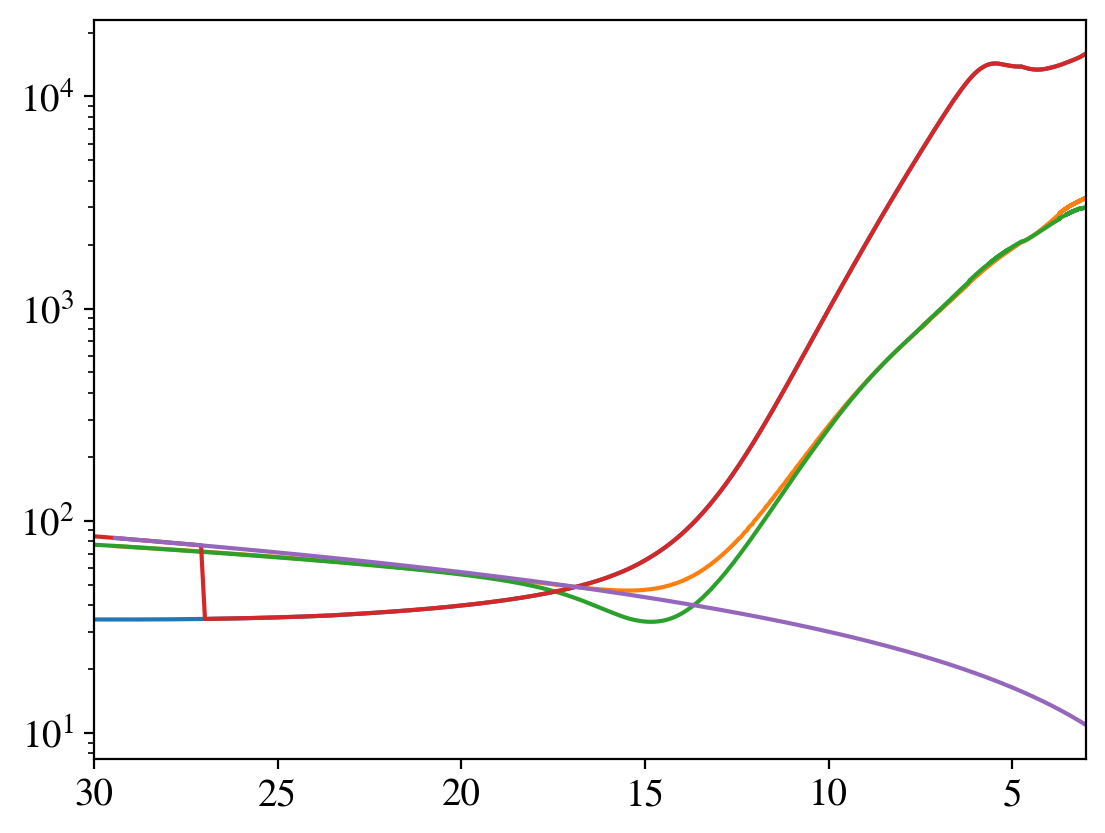

In [78]:
plt.plot(df_TSTK["redshift"], df_TSTK["T_vol"])

plt.plot(df_global["redshift"], df_global["T_S"])
plt.plot(df_AD["redshift"], df_AD["T_S"])
plt.plot(df_TSTK["redshift"], df_TSTK["T_S"])
plt.plot(df["redshift"], df["T_CMB"])
plt.xlim(30,3)



plt.yscale("log")

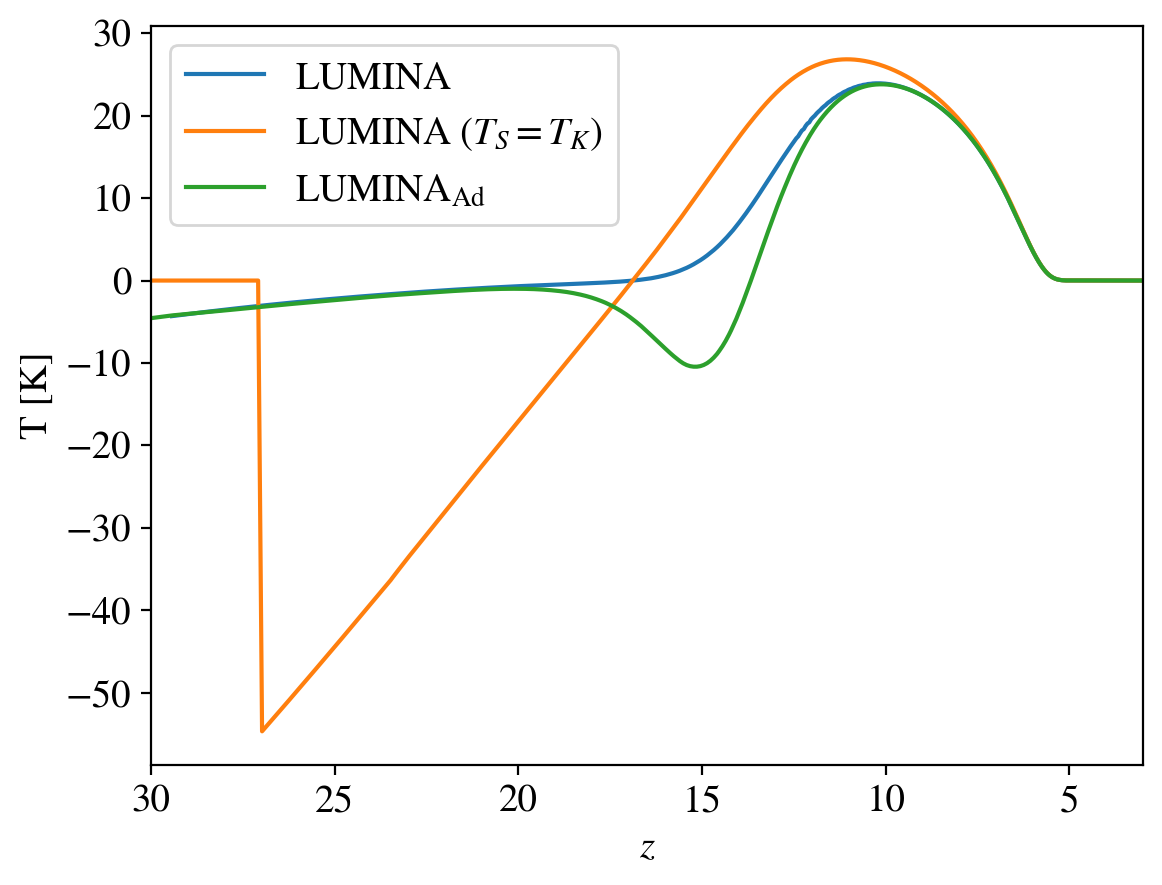

In [90]:
plt.plot(df_global["redshift"], df_global["T_b"], label=r"$\mathrm{LUMINA}$")
plt.plot(df_TSTK["redshift"], df_TSTK["T_b"], label=r"$\mathrm{LUMINA} \ (T_S = T_K)$")
plt.plot(df_AD["redshift"], df_AD["T_b"], label=r"$\mathrm{LUMINA_{Ad}}$")
plt.xlim(30,3)

plt.xlabel(r"$z$")
plt.ylabel(r"T [K]")
plt.legend()

In [25]:
# --- get_spec also hands back the age-resolved spectra ---
def get_spec(Z_target, return_ages=False):
    iZ = int(np.argmin(np.abs(spec.Metallicity - Z_target)))    # robust vs exact ==
    all_ages = spec.AgeGyr.copy()
    all_spectra = np.array([spec.full_spectrum(i, iZ)[1] for i in range(spec.N_age)])

    log_age_yr = np.log10(all_ages * 1e9)
    dlog = np.median(np.diff(log_age_yr))
    assert np.allclose(np.diff(log_age_yr), dlog), "age grid not uniform in log"
    hi = 10**(log_age_yr + dlog/2); lo = 10**(log_age_yr - dlog/2); lo[0] = 0.0
    dt_sec = (hi - lo) * 3.15576e7

    N_nu = np.sum(all_spectra * dt_sec[:, None], axis=0)
    if return_ages:
        return spec.freq, N_nu, all_spectra, all_ages, dt_sec
    return spec.freq, N_nu


# --- cosmic time: analytic flat LCDM, vectorised (don't call quad per element) ---
GYR = 3.15576e16
def t_of_z(z):
    A    = np.sqrt(OMEGA_Lambda / OMEGA_m)
    pref = 2.0 / (3.0 * H_0_cgs * np.sqrt(OMEGA_Lambda))          # seconds
    return pref * np.arcsinh(A * (1.0 + np.asarray(z, float))**-1.5) / GYR


# --- SFRD on a cosmic-time axis, zero before the first stars ---
_t = t_of_z(df["redshift"].values); _o = np.argsort(_t)
_t_s, _sfrd_s = _t[_o], df["SFRD"].values[_o]
def SFRD_t(t):
    return np.interp(t, _t_s, _sfrd_s, left=0.0, right=0.0)       # left=0 does the truncation


# --- restrict to the Lyman band once (keeps the convolution cheap) ---
freq, N_nu, L_age, tau_gyr, dtau_s = get_spec(1.0e-4, return_ages=True)
band = (freq >= 0.98*NU_LYMAN_ALPHA) & (freq <= 1.02*NU_LYMAN_LIMIT)
nu_b, L_b = freq[band], L_age[:, band]

i = np.argmin(np.abs(nu_b - NU_LYMAN_ALPHA))
w = L_b[:, i] * dtau_s
print("L-weighted mean age @1216A: %.1f Myr" % (1e3*np.sum(tau_gyr*w)/np.sum(w)))
print("median:                     %.1f Myr" % (1e3*np.interp(0.5, np.cumsum(w)/w.sum(), tau_gyr)))
# --- emissivity with the star formation history convolved in ---
def epsilon(nu, z):
    nu = np.atleast_1d(np.asarray(nu, float))
    t_now   = np.atleast_1d(t_of_z(z))                            # Gyr
    L_at_nu = np.array([np.interp(nu, nu_b, L_b[i]) for i in range(len(tau_gyr))])
    w       = SFRD_t(t_now[None, :] - tau_gyr[:, None])           # (N_age, len(nu))
    return np.sum(w * L_at_nu * dtau_s[:, None], axis=0) / m_p

NameError: name 'df' is not defined

In [24]:
band = (freq >= NU_LYMAN_ALPHA) & (freq <= NU_LYMAN_LIMIT)
for lab, N in [("1e-5",N_nu_5),("1e-4",N_nu_4),("1e-3",N_nu_3),("1e-2",N_nu_2)]:
    print(lab, np.trapezoid(N[band], freq[band]))

1e-5 21992.29993510885
1e-4 20573.305308800547
1e-3 17609.382896183684
1e-2 14062.168218479103


In [98]:
print(freq[0], freq[-1], np.all(np.diff(freq) > 0))

29979245800000.0 2.99792458e+18 True


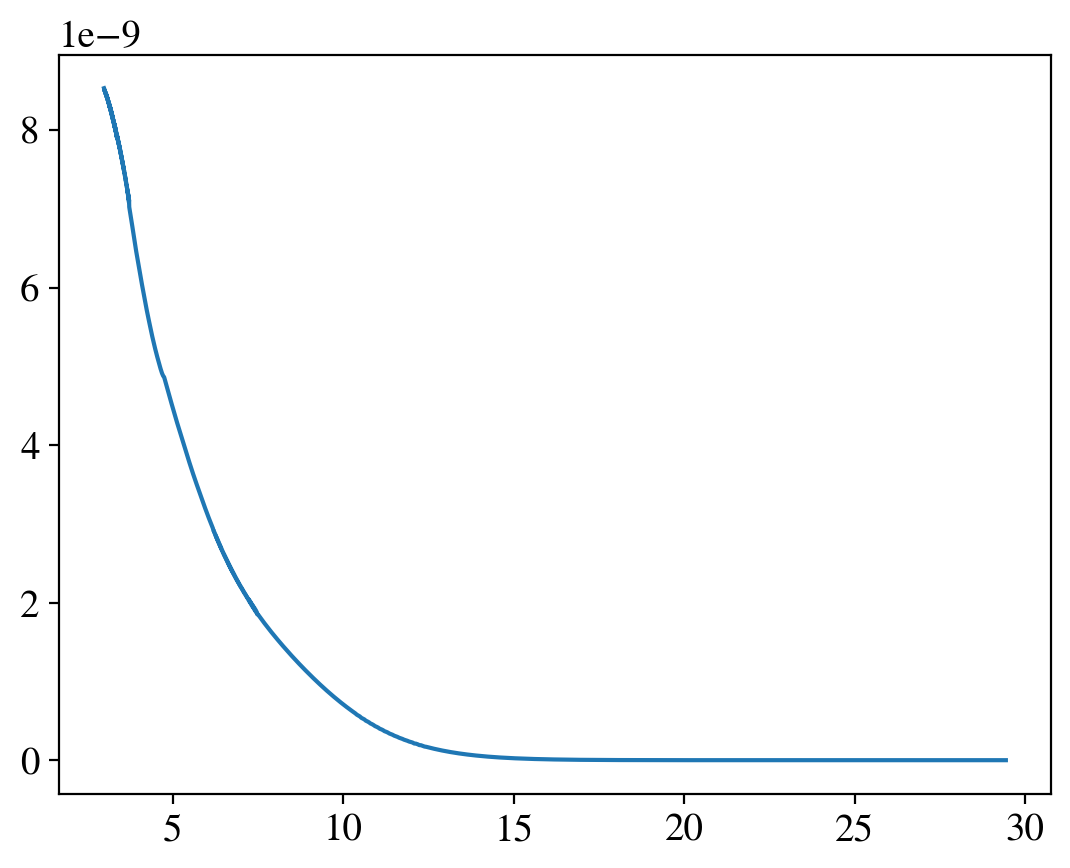

In [100]:
plt.plot(df_global["redshift"], df_global["J_alpha"], label="J_alpha (H)")


In [101]:
df_global["redshift"]

0       2.986690
1       2.990499
2       2.994312
3       2.998129
4       3.001949
         ...    
704    27.624245
705    28.065021
706    28.512585
707    28.967040
708    29.428494
Name: redshift, Length: 709, dtype: float64

In [102]:
import numpy as np

z_want = [20, 15, 12, 10]
z = df_global["redshift"].values
J = df_global["J_alpha"].values

# np.interp needs ascending x; your z is descending
order = np.argsort(z)
J_want = np.exp(np.interp(z_want, z[order], np.log(J[order])))

/tmp/ipykernel_1695403/1502838954.py:9: RuntimeWarning: divide by zero encountered in log
  J_want = np.exp(np.interp(z_want, z[order], np.log(J[order])))


In [103]:
df = df_global

array([2.55278323e-13, 2.47621895e-11, 2.28439347e-10, 7.08250037e-10])

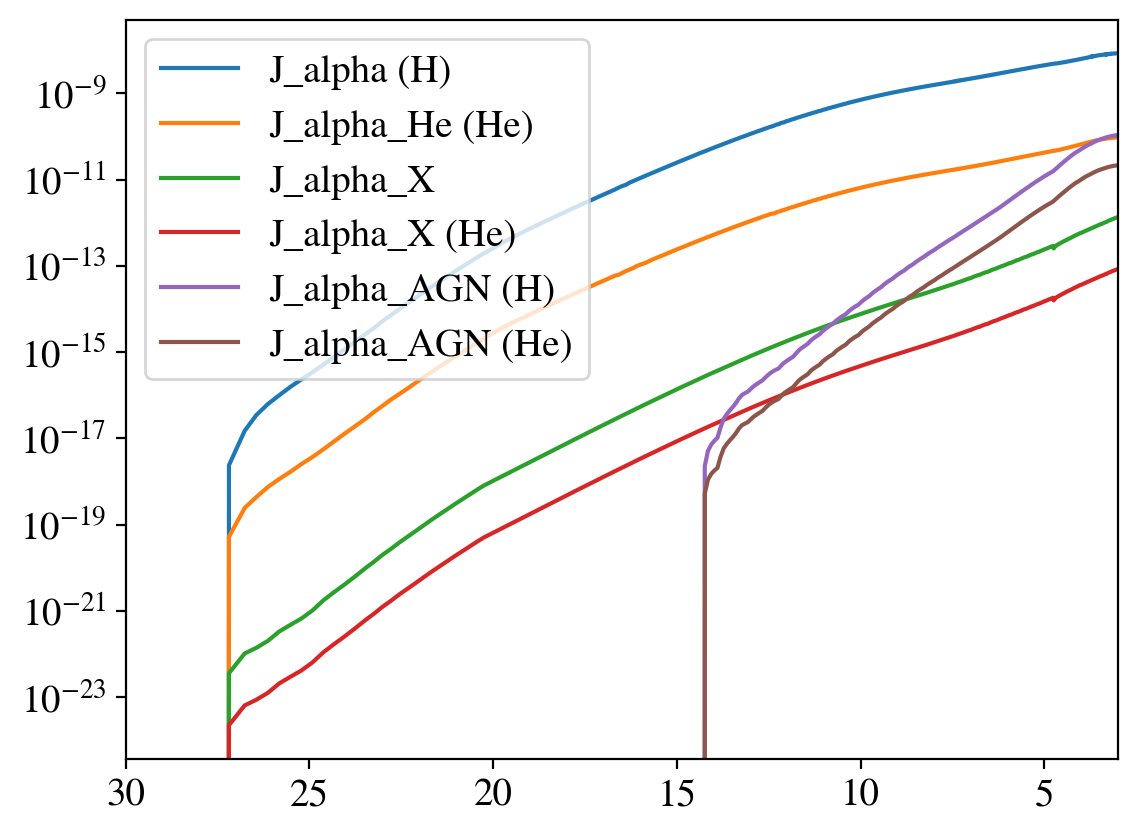

In [110]:
plt.plot(df["redshift"], df["J_alpha"], label="J_alpha (H)")
plt.plot(df["redshift"], df["J_alpha_He"], label="J_alpha_He (He)")
plt.plot(df["redshift"], df["J_alpha_X"], label="J_alpha_X")
plt.plot(df["redshift"], df["J_alpha_X_He"], label="J_alpha_X (He)")
plt.plot(df["redshift"], df["J_alpha_AGN"], label="J_alpha_AGN (H)")
plt.plot(df["redshift"], df["J_alpha_AGN_He"], label="J_alpha_AGN (He)")

#df["J_alpha_AGN_He"]
plt.legend()
plt.xlim(30,3)
plt.yscale("log")
